# Multilevel DART observation-diagnostic analysis

This notebook compares pressure-layer DART diagnostics across experiments. Set `COMPARISON_MODE` to `obs_space_s0`, `obs_space_s1`, `common_s0`, or `common_s1` to select the experiment group, diagnostic set, reference date, and output directory. Set `FIGURE_TYPE` to `time_series`, `raw_heatmap`, `metric_triangles`, or `variable_triangles`. Each figure type has a separate run block that prepares its own inputs and outputs only the selected type for `OBS_DIAG_CONFIG["plot"]["region"]`. Triangle preparation does not draw or save intermediate figures. Inputs are validated before large arrays are loaded.

## 1. Libraries


In [1]:
from pathlib import Path
import os
import sys
import warnings
import logging
from collections import defaultdict
from typing import Tuple, List, Dict, Optional
from datetime import datetime

import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xc
import xskillscore as xs

import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.cm import get_cmap

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker


/qfs/people/zhan391/.conda/envs/e3sm_analysis/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 2. User setup

Choose `FIGURE_TYPE` in the region/export setup cell:

- `time_series`: selected-variable multilevel time series.
- `raw_heatmap`: raw U/V/T/Q heatmaps, one figure per configured metric.
- `metric_triangles`: normalized four-metric triangles.
- `variable_triangles`: normalized U/V/T/Q triangles.

Run All generates only the selected figure type. After setup and function definitions have been executed, rerun only the matching run block to regenerate that type. Change the region in the same setup cell; change experiments and plot settings in the main User setup cell.

In [2]:
# =============================================================================
# TOP-LEVEL PATH PARAMETERS
# Edit these three paths to relocate inputs, the analysis checkout, or outputs.
# =============================================================================
from pathlib import Path
import os
import sys

INPUT_DATA_ROOT = Path("/compyfs/zhan391/v3_dart_cda_scratch")
WORK_DIR = Path("/compyfs/zhan391/work_package/e3sm_dart_analysis")
DIAGNOSTIC_OUTPUT_ROOT = Path("/compyfs/www/zhan391/e3sm_dart/diag_dart_2026")
WORKFLOW_NAME = "analysis_atm_da"


In [3]:
# =============================================================================
# USER SETUP
# Edit this cell to change paths, experiments, diagnostics, regions, or plots.
# =============================================================================

PROJECT_ROOT = WORK_DIR
DIAGNOSTIC_DIR = PROJECT_ROOT / "diagnostic"
if not (DIAGNOSTIC_DIR / "configs").is_dir() or not (DIAGNOSTIC_DIR / "util").is_dir():
    raise FileNotFoundError(f"Invalid E3SM-DART analysis root: {PROJECT_ROOT}")

DART_DATA_ROOT = INPUT_DATA_ROOT
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

DIAG_DATA_DIR = DIAGNOSTIC_OUTPUT_ROOT / "data"
DIAG_FIGURE_DIR = DIAGNOSTIC_OUTPUT_ROOT / "figure"

DIAG_PATH_TEMPLATES = {
    "cam": str(DART_DATA_ROOT / "%(RUNNAME)" / "%(CASENAME)" / "cam" / "dart_diagnostics" / "%(DIAG)"),
    "e3sm": str(DART_DATA_ROOT / "%(RUNNAME)" / "%(CASENAME)" / "eam" / "dart_diagnostics" / "%(DIAG)"),
}
CAM_LAYOUT_EXPERIMENTS = {"CAM80-S0", "CAM80-S1"}

# User setup: edit this dictionary when experiment names, runs, aliases, periods,
# or diagnostic sets change. The shared helper only validates and builds paths.
USER_EXPERIMENTS = {
    "CAM80-S0": {
        "run": "f.e21.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80",
        "period": "2011120100-2012010100",
    },
    "CAM80-S1": {
        "run": "f.e22.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80S1",
        "period": "2012050100-2012060100",
    },
    "CTRL10-S0": {
        "run": "CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "CTRLEN10",
        "period": "2011120100-2012010100",
    },
    "DART10-S0": {
        "run": "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "DARTEN10",
        "period": "2011120100-2012010100",
    },
    "DART20-S0": {
        "run": "DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en20",
        "alias": "DARTEN20",
        "period": "2011120100-2012010100",
    },
    "DART40INF0p6-S0": {
        "run": "DARTEN40_INF0p6_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011120100-2012010100",
    },
    "DART40-S0": {
        "run": "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011120100-2012010100",
    },
    "DART40-S1": {
        "run": "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40S1",
        "period": "2012050100-2012060100",
    },
}

# User setup: change this tuple when the available diagnostic sets change.
USER_DIAG_SETS = ("obs_seq", "obs_diag", "obs_common", "closest_member", "cam6_common")

# Optional layer for temporary add/update/remove changes. Set an experiment to None
# here to remove it without touching USER_EXPERIMENTS.
USER_EXPERIMENT_OVERRIDES = {}

for experiment_name, experiment in USER_EXPERIMENTS.items():
    layout = "cam" if experiment_name in CAM_LAYOUT_EXPERIMENTS else "e3sm"
    experiment["path_template"] = DIAG_PATH_TEMPLATES[layout]

# === Comparison mode: select one of the four supported experiment groups ===
#COMPARISON_MODE = "common_s0" 
COMPARISON_MODE = "obs_space_s0"

S0_EXPERIMENTS = ("CAM80-S0", "DART10-S0", "DART20-S0", "DART40-S0")
S1_EXPERIMENTS = ("CAM80-S1", "DART40-S1")
COMPARISON_MODE_CONFIGS = {
    # Standard observation-space diagnostics.
    "obs_space_s0": {
        "diag_set": "diag2",
        "experiments": S0_EXPERIMENTS,
        "tunit": "2011-12-01",
        "level_name": "plevel",
    },
    "obs_space_s1": {
        "diag_set": "diag2",
        "experiments": S1_EXPERIMENTS,
        "tunit": "2012-05-01",
        "level_name": "plevel",
    },
    # Diagnostics restricted to observations common to all experiments.
    "common_s0": {
        "diag_set": "diag5",
        "experiments": S0_EXPERIMENTS,
        "tunit": "2011-12-01",
        "level_name": "plevel",
    },
    "common_s1": {
        "diag_set": "diag5",
        "experiments": S1_EXPERIMENTS,
        "tunit": "2012-05-01",
        "level_name": "plevel",
    },
}
if COMPARISON_MODE not in COMPARISON_MODE_CONFIGS:
    raise ValueError(
        f"Unknown COMPARISON_MODE={COMPARISON_MODE!r}; "
        f"choose from {tuple(COMPARISON_MODE_CONFIGS)}."
    )
ACTIVE_MODE = COMPARISON_MODE_CONFIGS[COMPARISON_MODE]
ACTIVE_EXPERIMENTS = list(ACTIVE_MODE["experiments"])

# === Notebook configuration: adjust analysis and plotting here ===
OBS_DIAG_CONFIG = {
    "comparison_mode": COMPARISON_MODE,
    "selected_variable": "Temperature",  # U_WIND, V_WIND, Temperature, Humidity
    "plot": {
        "region": "NH",
        "plot_levs": None,  # None selects every other available pressure level
        "comparison_mode": COMPARISON_MODE,
        "exps": ACTIVE_EXPERIMENTS,
        "labels": ACTIVE_EXPERIMENTS.copy(),
        "diag_set": ACTIVE_MODE["diag_set"],
        "level_name": ACTIVE_MODE["level_name"],
        "dtype": "guess",
        "tunit": ACTIVE_MODE["tunit"],
        "xmin": 0,
        "xmax": 29.75,  # completes the 26–30 window for six-hourly data
        "show": True,
        "save": True,
        "panel_width": 7,
        "panel_height": 13,
        "fontz": 16,
        "dpi": 600,
        "use_dask": True,
        "dask_chunks": {"time": 31, "copy": -1, "plevel": -1, "region": 1},
        "persist_means": False,
    },
    # Source data use DART serial days at six-hour cadence; None disables the check.
    "expected_time_increment_days": 0.25,
}

HEATMAP_VARIABLES = {
    "U": "U_WIND",
    "V": "V_WIND",
    "T": "Temperature",
    "Q": "Humidity",
}
HEATMAP_VAR_LABELS = {
    "U_WIND": "(U)",
    "V_WIND": "(V)",
    "Temperature": "(T)",
    "Humidity": "(Q)",
}
TRIANGLE_METRIC_LAYOUT = {
    "top": "spread",
    "right": "nused",
    "bottom": "rejection_rate",
    "left": "rmse",
}
VARIABLE_TRIANGLE_LAYOUT = {
    "top": "U_WIND",
    "right": "V_WIND",
    "bottom": "Temperature",
    "left": "Humidity",
}

DIAGNOSTIC_SCALING_CONFIG = {
    "ratio_floor": 1.0e-4,
    "rmse_epsilon": 1.0e-12,
    "spread_score_base": 2.0,
    "rejection_percent_scale": 100.0,
    "rejection_percent_tolerance": 1.0e-8,
    "nused_epsilon": 1.0e-12,
    "nused_reference_percentile": 95.0,
    "raw_heatmap_robust_percentile": 98.0,
    "spread_heatmap_bounds": (0.3, 0.5, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.5, 2.0),
    "spread_overview_range": (0.5, 1.0, 1.5),
    "spread_overview_ticks": (0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.5),
}
FONT_SCALE_CONFIG = {
    "small_key": 0.55,
    "count_key": 0.55,
    "variable_key": 0.75,
    "triangle_tick": 0.75,
    "triangle_ytick": 0.75,
    "triangle_ylabel": 0.85,
    "raw_tick": 0.80,
    "compact": 0.85,
    "triangle_xlabel": 0.85,
    "raw_label": 0.95,
    "axis_label": 0.90,
    "legend_and_ticks": 0.90,
    "panel_title": 1.0,
    "figure_title": 1.0,
}

PLOT_STYLE_CONFIG = {
    "reference_band_color": "grey",
    "reference_band_alpha": 0.25,
    "reference_line_color": "k",
    "reference_line_style": "--",
    "reference_line_width": 1.2,
    "title_pad": 8,
    "legend_columns": 2,
    "shared_legend_anchor": (0.5, -0.03),
    "raw_minor_tick_width": 0.5,
    "raw_minor_tick_color": "0.6",
    "raw_colorbar_pad": 0.02,
    "raw_colorbar_shrink": 0.85,
    "triangle_extra_width": 1.4,
    "triangle_margins": {"left": 0.12, "right": 0.86, "bottom": 0.12, "top": 0.94},
    "cell_edge_color": "lightgrey",
    "cell_edge_width": 0.01,
    "hatch_color": "0.72",
    "hatch_line_width": 0.25,
    "zero_used_hatch": "xxxx",
    "missing_reference_hatch": "////",
    "grid_zorder": 3,
    "spinup_line_color": "black",
    "spinup_line_style": "--",
    "spinup_line_width": 0.8,
    "spinup_line_zorder": 6,
    "triangle_title_pad": 2,
    "experiment_fontweight": "normal",
    "triangle_tick_rotation": 40,
    "tick_width": 1.0,
    "shared_xlabel": f"Days since {ACTIVE_MODE['tunit']}",
    "shared_xlabel_y": 0.040,
    "key_axes": (0.875, 0.84, 0.105, 0.14),
    "key_box_aspect": 0.75,
    "key_line_color": "black",
    "key_line_width": 0.7,
    "key_line_spacing": 0.9,
    "metric_key_top_y": 0.84,
    "metric_key_bottom_y": 0.14,
    "colorbar_axes": (0.89, 0.16, 0.025, 0.62),
    "colorbar_orientation": "vertical",
    "colorbar_spacing": "uniform",
    "colorbar_extend": "both",
    "colorbar_draw_edges": True,
    "colorbar_edge_color": "black",
    "colorbar_edge_width": 0.5,
    "colorbar_label": "Normalized Diagnostic Score",
    "colorbar_tick_format": "%.1f",
    "better_position": (0.9025, 0.820),
    "worse_position": (0.9025, 0.120),
    "save_bbox": "tight",
    "time_series_format": "pdf",
    "raw_heatmap_format": "pdf",
    "triangle_format": "pdf",
    "series_line_width": 2.0,
    "series_alpha": 0.9,
    "overview_figsize": (16, 10),
    "overview_dpi": 300,
    "overview_title_font": 13,
    "overview_tick_font": 10,
    "overview_xlabel_font": 11,
    "overview_suptitle_font": 18,
    "overview_ylabel_font": 14,
    "overview_note_font": 11,
    "overview_ylabel_position": (0.03, 0.55),
    "overview_note_position": (0.5, 0.03),
    "overview_ylabel_rotation": 90,
    "overview_colorbar_orientation": "horizontal",
    "overview_colorbar_fraction": 0.05,
    "overview_colorbar_pad": 0.12,
    "overview_note_color": "0.35",
    "spread_heatmap_cmap": "coolwarm",
    "rejection_heatmap_cmap": "YlOrRd",
    "rmse_heatmap_cmap": "RdYlBu_r",
    "default_heatmap_cmap": "viridis",
    "missing_color": "0.85",
    "two_sided_extend": "both",
    "upper_extend": "max",
}


SCORE_CMAP = plt.get_cmap("RdYlGn").resampled(10)
SCORE_CMAP.set_bad("#eeeeee")
SCORE_CMAP.set_under("#a50026")
SCORE_CMAP.set_over("#006837")
FINAL_HEATMAP_CONFIG = {
    # Shared data preparation for both final figures.
    "metrics": ("rmse", "spread", "nused", "rejection_rate"),
    "levels": None,  # None selects pressure levels common to U/V/T/Q
    "experiments": None,  # None selects experiments common to U/V/T/Q
    "xticks": (0, 7, 14, 21, 28),
    "time_aggregation": "5day",  # "daily" or "5day"
    "minimum_5day_coverage": 0.8,
    # Intermediate/raw heatmaps used to prepare the normalized scores.
    "raw_panel_width": 4.5,
    "raw_panel_height": 6.5,
    "raw_fontz": 18,
    "raw_dpi": 300,
    "raw_show": False,
    "raw_save": False,
    # Normalized triangular figures.
    "reference_experiment": ACTIVE_EXPERIMENTS[0],
    "excluded_5day_bins": {"DART10-S0": (5,)},
    "score_cmap": SCORE_CMAP,
    "score_boundaries": tuple(np.linspace(0.0, 1.0, 11)),
    "panel_width": 2.6,
    "panel_aspect_ratio": 1.25,
    "column_space": 0.05,
    "row_space": 0.20,
    "spinup_end_day": 10,
    "fontz": 18,
    "dpi": 600,
    "show": True,
    "save": True,
}


In [4]:
# Primary region and export defaults.
OBS_DIAG_CONFIG["plot"]["region"] = "GB"  # DART's global region
FINAL_HEATMAP_CONFIG["raw_save"] = True
plt.rcParams["savefig.pad_inches"] = 0.0
FINAL_HEATMAP_CONFIG["excluded_5day_bins"] = {}
3

FIGURE_TYPE = "metric_triangles"
FIGURE_TYPES = ("time_series", "raw_heatmap", "metric_triangles", "variable_triangles")
if FIGURE_TYPE not in FIGURE_TYPES:
    raise ValueError(f"Unknown FIGURE_TYPE={FIGURE_TYPE!r}; choose from {FIGURE_TYPES}.")

## 3. Project setup


In [5]:
# Derived paths: built from the parameters above.
import sys
from pathlib import Path

DIAGNOSTIC_DIR = WORK_DIR / "diagnostic"
if not DIAGNOSTIC_DIR.is_dir():
    raise FileNotFoundError(f"Diagnostic work directory not found: {DIAGNOSTIC_DIR}")
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

from configs.output_paths import workflow_output_dirs
WORKFLOW_DATA_DIR, WORKFLOW_FIGURE_DIR = workflow_output_dirs(
    WORKFLOW_NAME,
    output_root=DIAGNOSTIC_OUTPUT_ROOT,
)


In [6]:
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

from util.dart_observation_diagnostics import (
    DartObsDiagReader
)

from util.dask_helpers import configure_dask, persist_if_dask

# === Suppress warnings globally ===
warnings.filterwarnings("ignore")
from configs.analysis_da_experiment_config import extract_obs_diag_config

def final_heatmap_kwargs(kind, **overrides):
    """Return function arguments derived from the single final-heatmap config."""
    data_keys = ("metrics", "levels", "experiments", "xticks", "time_aggregation", "minimum_5day_coverage")
    common_keys = ("score_cmap", "score_boundaries", "panel_width", "column_space", "row_space", "spinup_end_day", "fontz", "dpi", "show", "save")
    if kind == "raw":
        result = {key: FINAL_HEATMAP_CONFIG[key] for key in data_keys}
        for key in ("panel_width", "panel_height", "fontz", "dpi", "show", "save"):
            result[key] = FINAL_HEATMAP_CONFIG[f"raw_{key}"]
    elif kind == "metric":
        metric_keys = ("reference_experiment", "excluded_5day_bins")
        result = {key: FINAL_HEATMAP_CONFIG[key] for key in (*metric_keys, *common_keys)}
        result["panel_height"] = FINAL_HEATMAP_CONFIG["panel_width"] * FINAL_HEATMAP_CONFIG["panel_aspect_ratio"]
        result["nused_reference_percentile"] = DIAGNOSTIC_SCALING_CONFIG["nused_reference_percentile"]
    elif kind == "variable":
        result = {key: FINAL_HEATMAP_CONFIG[key] for key in common_keys}
        result["panel_height"] = FINAL_HEATMAP_CONFIG["panel_width"] * FINAL_HEATMAP_CONFIG["panel_aspect_ratio"]
    else:
        raise ValueError(f"Unknown final heatmap configuration kind: {kind}")
    result.update(overrides)
    return result


def extract_exp_info(exp_name: str = None) -> dict:
    return extract_obs_diag_config(
        exp_name=exp_name,
        experiments=USER_EXPERIMENTS,
        data_path=DART_DATA_ROOT,
        diag_sets=USER_DIAG_SETS,
        experiment_overrides=USER_EXPERIMENT_OVERRIDES,
    )
def validate_obs_diag_inputs(reader, experiments, diag_set):
    missing = []
    for experiment_name, experiment in experiments.items():
        directory, filename = reader.resolve_dart_file_path(
            experiment, experiment_name, diag_set, experiment["period"]
        )
        file_path = Path(directory) / filename
        if not file_path.is_file():
            missing.append(file_path)
    if missing:
        formatted = "\n".join(f"  - {file_path}" for file_path in missing)
        raise FileNotFoundError("Missing DART diagnostic inputs:\n" + formatted)


## 4. Multilevel plotting class


In [7]:
class ObsDiagPlotter:
    def __init__(
        self, var, var_dict, data_dict, fig_path,
        plevstr, region = None, regnam=None
    ):
        self.var = var
        self.var_dict = var_dict or {}
        self.data_dict = data_dict or {}
        self.fig_path = fig_path
        self.plevstr = plevstr or []
        self.region = region
        self.regnam = regnam
        self._prepare_common()

    def _prepare_common(self):
        self.cmap = {
            'blue': '#377eb8', 'orange': '#ff7f00', 'green': '#4daf4a',
            'pink': '#f781bf', 'brown': '#a65628', 'purple': '#984ea3',
            'gray': '#999999', 'red': '#e41a1c', 'yellow': '#dede00'
        }

    def _set_axes_limits(self, ax, xlim=None, ylim=None, yticks=None, xticks=None):
        if xlim is not None: ax.set_xlim(*xlim)
        if ylim is not None: ax.set_ylim(*ylim)
        if yticks is not None: ax.set_yticks(yticks)
        if xticks is not None: ax.set_xticks(xticks)

    # NEW: robust getter for inner var-config
    def _varcfg(self):
        """Return inner var-config whether var_dict is an inner dict or a single-entry wrapper."""
        vd = self.var_dict
        if isinstance(vd, dict) and 'y1aix' in vd:
            return vd
        if isinstance(vd, dict) and len(vd) == 1:
            return next(iter(vd.values()))
        raise ValueError(
            "var_dict not recognized. Pass inner dict with keys like 'y1aix'/'y2aix', "
            "or a single-entry wrapper {var_key: inner}."
        )

    def check_flat_lev_consistency(self, lev_dict):
        ref_var = next(iter(lev_dict))
        reference = lev_dict[ref_var]
        for var, lev in lev_dict.items():
            if lev != reference:
                raise ValueError(
                    f"Inconsistent pressure level list for variable '{var}'.\n"
                    f"Expected: {reference}\nFound:    {lev}"
                )
        print("All level lists are consistent across variables.")
        return reference
    
    def build_ts_var_dict(
        self, var_key: str = None, name: str = None,
        y1axis: list = None, y2axis: list = None
    ) -> dict:
        var_key = var_key or 'RADIOSONDE_U'
        name = name or 'RADIOSONDE_U_WIND_COMPONENT'
        entry = {
            'name': name,
            'lev_type': 'pressure',
            'CopySpread': 'totalspread',
            'CopyRMSE': 'rmse',
            'CopyNposs': 'Nposs',
            'CopyNused': 'Nused',
            'type1': 'guess',
            'type2': 'VPguess',
            'type3': 'guess_RankHist',
            'y1aix': y1axis if y1axis is not None else [0, 10],
            'y2aix': [0, 100],
            'y1aix0': y2axis if y2axis is not None else [0, 10],
            'y2aix0': [0, 100],
        }
        return {var_key: entry}
    
    def compute_experiment_means(
        self,
        data_dict,
        diagnostic_keys_to_average,
        diagnostic_keys_to_sum=None,
        diagnostic_keys_to_pool=None,
        persist=False,
    ):
        diagnostic_keys_to_sum = diagnostic_keys_to_sum or []
        if not data_dict:
            raise ValueError("data_dict is empty; no observation types are available to pool.")
        sample_var_data = next(iter(data_dict.values()))
        experiments = list(sample_var_data.keys())
        all_diagnostic_keys = set()
        for var_data in data_dict.values():
            for exp_data in var_data.values():
                all_diagnostic_keys.update(exp_data.keys())
        all_diagnostic_keys.update(diagnostic_keys_to_average)
        all_diagnostic_keys.update(diagnostic_keys_to_sum)
        all_diagnostic_keys.update(diagnostic_keys_to_pool or {})
        mean_dict = {}
        for exp in experiments:
            reference_time = reference_var = None
            for var, var_data in data_dict.items():
                if exp not in var_data or "time" not in var_data[exp]:
                    continue
                current_time = np.asarray(var_data[exp]["time"])
                if reference_time is None:
                    reference_time, reference_var = current_time, var
                elif not np.array_equal(reference_time, current_time):
                    raise ValueError(
                        f"Inconsistent time coordinates for {var} and {reference_var}, experiment {exp}"
                    )
            mean_dict[exp] = {}
            for key in all_diagnostic_keys:
                if key in (diagnostic_keys_to_pool or {}):
                    # Count-weighted pooling: sqrt(sum(N * val^2) / sum(N)).
                    # Used for rmse and spread so that observation types with more
                    # assimilated observations receive proportionally greater weight.
                    # Intentionally eager: persist=False does not retain laziness here.
                    weight_key = (diagnostic_keys_to_pool or {})[key]
                    valid_vals, valid_weights = [], []
                    for var in data_dict:
                        ev = data_dict[var].get(exp, {}).get(key, None)
                        paired_key = "spread" if key == "rmse" else "rmse"
                        ep = data_dict[var].get(exp, {}).get(paired_key, None)
                        ew = data_dict[var].get(exp, {}).get(weight_key, None)
                        if ev is None or ep is None or ew is None:
                            continue
                        if hasattr(ev, "compute"): ev = ev.compute()
                        if hasattr(ep, "compute"): ep = ep.compute()
                        if hasattr(ew, "compute"): ew = ew.compute()
                        ev = np.asarray(ev.values if hasattr(ev, "values") else ev, dtype=float)
                        ep = np.asarray(ep.values if hasattr(ep, "values") else ep, dtype=float)
                        ew = np.asarray(ew.values if hasattr(ew, "values") else ew, dtype=float)
                        if ev.size == 0 or ep.size == 0 or ew.size == 0:
                            continue
                        if ev.shape != ep.shape or ev.shape != ew.shape:
                            raise ValueError(
                                f"Shape mismatch for {key}/{paired_key}/{weight_key} in "
                                f"{var}, experiment {exp}: {ev.shape}, {ep.shape}, {ew.shape}"
                            )
                        ev = np.where(np.isfinite(ep), ev, np.nan)
                        valid_vals.append(ev)
                        valid_weights.append(ew)
                    if valid_vals:
                        sv = np.stack(valid_vals, axis=0)
                        sw = np.stack(valid_weights, axis=0)
                        vmask = np.isfinite(sv) & np.isfinite(sw) & (sw > 0)
                        w_safe = np.where(vmask, sw, 0.0)
                        sum_w   = w_safe.sum(axis=0)
                        sum_wv2 = (w_safe * np.where(vmask, sv ** 2, 0.0)).sum(axis=0)
                        metric_array = np.sqrt(
                            np.divide(sum_wv2, sum_w,
                                      out=np.full_like(sum_w, np.nan),
                                      where=sum_w > 0)
                        )
                    else:
                        metric_array = None
                    mean_dict[exp][key] = metric_array

                elif key in diagnostic_keys_to_average or key in diagnostic_keys_to_sum:
                    valid_data = []
                    for var in data_dict:
                        entry = data_dict[var].get(exp, {}).get(key, None)
                        if entry is None or not hasattr(entry, "size") or entry.size == 0:
                            continue
                        valid_data.append(entry)
                    if valid_data:
                        try:
                            if any(isinstance(arr, xr.DataArray) for arr in valid_data):
                                valid_data = [
                                    arr if isinstance(arr, xr.DataArray) else xr.DataArray(arr)
                                    for arr in valid_data
                                ]
                                stacked = xr.concat(valid_data, dim="obs_type")
                                if key in diagnostic_keys_to_sum:
                                    metric_array = stacked.sum(dim="obs_type", skipna=True, min_count=1)
                                else:
                                    metric_array = stacked.mean(dim="obs_type", skipna=True)
                                metric_array = persist_if_dask(metric_array, persist)
                            else:
                                stacked = np.stack(valid_data, axis=0)
                                if key in diagnostic_keys_to_sum:
                                    finite_count = np.isfinite(stacked).sum(axis=0)
                                    metric_array = np.nansum(stacked, axis=0)
                                    metric_array = np.where(finite_count > 0, metric_array, np.nan)
                                else:
                                    metric_array = np.nanmean(stacked, axis=0)
                        except ValueError:
                            shapes = [arr.shape for arr in valid_data]
                            print(f"[WARN] Shape mismatch for '{key}' in '{exp}': {shapes}. Skipping metric.")
                            metric_array = None
                    else:
                        metric_array = None
                    mean_dict[exp][key] = metric_array
                else:
                    values = [
                        data_dict[var][exp][key]
                        for var in data_dict
                        if exp in data_dict[var] and key in data_dict[var][exp]
                    ]
                    if not values:
                        mean_dict[exp][key] = None
                        continue
                    first_val = values[0]
                    if all(np.array_equal(np.asarray(first_val), np.asarray(v)) for v in values):
                        mean_dict[exp][key] = first_val
                    else:
                        raise ValueError(
                            f"Inconsistent values for diagnostic key '{key}' in experiment '{exp}'."
                        )
        return mean_dict
    
    def _auto_ylims(self, values, *, pad_frac=0.25, symmetric=False):
        """
        Compute nice y-limits from a 1D array-like metric.

        Parameters
        ----------
        values : array-like
            Metric values (nan-safe).
        pad_frac : float
            Fractional padding on each side (default 0.10 = 10%).
        symmetric : bool
            If True, make y-limits symmetric around zero.
        """
        import numpy as np

        arr = np.asarray(values, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return (-1, 1)  # fallback

        vmin, vmax = arr.min(), arr.max()

        # If all values identical → pad around that value
        if np.isclose(vmin, vmax):
            delta = abs(vmin) * pad_frac if vmin != 0 else 1.0
            return (vmin - delta, vmax + delta)

        if symmetric:
            bound = max(abs(vmin), abs(vmax))
            pad = bound * pad_frac
            return (-bound - pad, bound + pad)

        # Regular: padded min/max
        pad = (vmax - vmin) * pad_frac
        return (vmin - pad, vmax + pad)

    def plot_metric_by_experiment(
            self,
            plev_subset,
            metrics,
            metric_dict,
            xmin,
            xmax,
            xunit,
            fontz,
            dpi,
            panel_width,
            panel_height,
            show,
            save,
            fig_idx=0,
            shared_legend=True, 
        ):
        """
        Generate one figure with one row per experiment and one column per metric.
        The first column is RMSE and the second column is Spread/RMSE when those
        metrics are passed in that order.
        """

        exp_names = list(self.data_dict.keys())
        nrows = len(exp_names)
        ncols = len(metrics)

        if ncols == 0:
            raise ValueError("At least one metric is required for plotting.")

        tableau = [
            "#4e79a7", "#f28e2b", "#e15759", "#76b7b2",
            "#59a14f", "#edc948", "#b07aa1", "#ff9da7"
        ]

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(panel_width * ncols, panel_height),
            sharex=True,
            squeeze=False,
        )

        legend_handles = None
        legend_labels = None

        for i, exp in enumerate(exp_names):
            d = self.data_dict[exp]
            time = np.asarray(d["time"])
            mask = (time >= xmin) & (time <= xmax)
            time_f = time[mask]

            for j, metric in enumerate(metrics):
                ax = axes[i, j]

                if metric not in d or d[metric] is None:
                    ax.text(
                        0.5,
                        0.5,
                        f"{metric} not available\nrerun the reader/class cells",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=fontz * FONT_SCALE_CONFIG["axis_label"],
                    )
                    ax.set_axis_off()
                    continue

                if metric == "spread":
                    low, high = metric_dict["spread"]["reliability_band"]
                    ax.axhspan(low, high, color=PLOT_STYLE_CONFIG["reference_band_color"], alpha=PLOT_STYLE_CONFIG["reference_band_alpha"], zorder=0)
                    ax.axhline(1.0, color=PLOT_STYLE_CONFIG["reference_line_color"], linestyle=PLOT_STYLE_CONFIG["reference_line_style"], lw=PLOT_STYLE_CONFIG["reference_line_width"], zorder=1)

                for il, lev in enumerate(plev_subset):
                    color = tableau[il % len(tableau)]

                    if metric == "spread":
                        if isinstance(d["spread"], xr.DataArray) or isinstance(d["rmse"], xr.DataArray):
                            spread = d["spread"].clip(min=DIAGNOSTIC_SCALING_CONFIG["ratio_floor"])
                            rmse = d["rmse"].clip(min=DIAGNOSTIC_SCALING_CONFIG["ratio_floor"])
                        else:
                            spread = np.clip(np.asarray(d["spread"]), DIAGNOSTIC_SCALING_CONFIG["ratio_floor"], None)
                            rmse = np.clip(np.asarray(d["rmse"]), DIAGNOSTIC_SCALING_CONFIG["ratio_floor"], None)
                        values = spread / rmse
                    elif metric == "rmse":
                        values = d["rmse"]
                    else:
                        values = d[metric]

                    if values.ndim != 2:
                        raise ValueError("Metric array must be time x level.")
                    if lev not in self.plevstr:
                        print(f"[WARN] Requested level '{lev}' not found in lev_str; skipping.")
                        continue

                    ilev = self.plevstr.index(lev)
                    if isinstance(values, xr.DataArray):
                        vals = values.isel({values.dims[0]: mask, values.dims[1]: ilev}).compute().values
                    else:
                        vals = np.asarray(values)[mask, ilev]
                    ax.plot(
                        time_f,
                        vals,
                        label=lev.replace(" ", ""),
                        color=color,
                        lw=PLOT_STYLE_CONFIG["series_line_width"],
                        alpha=PLOT_STYLE_CONFIG["series_alpha"],
                    )

                cfg = metric_dict[metric]
                if cfg.get("ylim") is not None:
                    ax.set_ylim(cfg["ylim"])
                if cfg.get("yscale"):
                    ax.set_yscale(cfg["yscale"])
                ax.set_ylabel(cfg["unit"], fontsize=fontz)
                ax.tick_params(labelsize=fontz * FONT_SCALE_CONFIG["legend_and_ticks"])

                panel_letter = chr(97 + i * ncols + j + fig_idx)
                ax.set_title(
                    f"({panel_letter}) {exp} ({self.var})",
                    fontsize=fontz * FONT_SCALE_CONFIG["panel_title"],
                    pad=PLOT_STYLE_CONFIG["title_pad"],
                    loc="left",
                )
                ax.set_title(
                    cfg["name"],
                    fontsize=fontz * FONT_SCALE_CONFIG["panel_title"],
                    pad=PLOT_STYLE_CONFIG["title_pad"],
                    loc="right",
                )

                if i == nrows - 1:
                    ax.set_xlabel(f"Days since {xunit}", fontsize=fontz)

                if not shared_legend:
                    ax.legend(fontsize=fontz * FONT_SCALE_CONFIG["legend_and_ticks"], ncol=PLOT_STYLE_CONFIG["legend_columns"])
                elif legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()

        if shared_legend and legend_handles:
            fig.legend(
                legend_handles,
                legend_labels,
                loc="lower center",
                ncol=max(1, len(legend_labels) // 2 + 1),
                fontsize=fontz * FONT_SCALE_CONFIG["legend_and_ticks"],
                frameon=True,
                bbox_to_anchor=PLOT_STYLE_CONFIG["shared_legend_anchor"],
            )

        fig.tight_layout()
        if show:
            plt.show()
        if save:
            metric_tag = "_".join(metrics)
            fname = os.path.join(
                self.fig_path,
                f"fig_metric_{metric_tag}_{self.var}_{self.region}.{PLOT_STYLE_CONFIG['time_series_format']}",
            )
            fig.savefig(fname, dpi=dpi, bbox_inches=PLOT_STYLE_CONFIG["save_bbox"])
            plt.close(fig)


In [8]:
def _plot_metric_by_experiment_clean(
    self,
    plev_subset,
    metrics,
    metric_dict,
    xmin,
    xmax,
    xunit,
    fontz,
    dpi,
    panel_width,
    panel_height,
    show,
    save,
    fig_idx=0,
    shared_legend=True,
):
    if not show and not save:
        return
    exp_names = list(self.data_dict)
    nrows = len(exp_names)
    ncols = len(metrics)
    if ncols == 0:
        raise ValueError("At least one metric is required for plotting.")

    tableau = [
        "#4e79a7", "#f28e2b", "#e15759", "#76b7b2",
        "#59a14f", "#edc948", "#b07aa1", "#ff9da7",
    ]
    figure, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width * ncols, panel_height),
        sharex=True,
        squeeze=False,
    )
    legend_handles = None
    legend_labels = None

    for row, experiment in enumerate(exp_names):
        data = self.data_dict[experiment]
        time = np.asarray(data["time"], dtype=float)
        mask = (time >= xmin) & (time <= xmax)
        time_filtered = time[mask]

        for column, metric in enumerate(metrics):
            axis = axes[row, column]
            if metric not in data or data[metric] is None:
                axis.text(
                    0.5, 0.5, f"{metric} not available",
                    transform=axis.transAxes, ha="center", va="center",
                    fontsize=fontz * FONT_SCALE_CONFIG["axis_label"],
                )
                axis.set_axis_off()
                continue

            if metric == "spread":
                low, high = metric_dict["spread"]["reliability_band"]
                axis.axhspan(
                    low, high,
                    color=PLOT_STYLE_CONFIG["reference_band_color"],
                    alpha=PLOT_STYLE_CONFIG["reference_band_alpha"], zorder=0,
                )
                axis.axhline(
                    1.0, color=PLOT_STYLE_CONFIG["reference_line_color"],
                    linestyle=PLOT_STYLE_CONFIG["reference_line_style"],
                    lw=PLOT_STYLE_CONFIG["reference_line_width"], zorder=1,
                )

            for level_index, level in enumerate(plev_subset):
                color = tableau[level_index % len(tableau)]
                if metric == "spread":
                    if isinstance(data["spread"], xr.DataArray) or isinstance(data["rmse"], xr.DataArray):
                        spread = data["spread"].clip(min=DIAGNOSTIC_SCALING_CONFIG["ratio_floor"])
                        rmse = data["rmse"].clip(min=DIAGNOSTIC_SCALING_CONFIG["ratio_floor"])
                    else:
                        spread = np.clip(
                            np.asarray(data["spread"]),
                            DIAGNOSTIC_SCALING_CONFIG["ratio_floor"], None,
                        )
                        rmse = np.clip(
                            np.asarray(data["rmse"]),
                            DIAGNOSTIC_SCALING_CONFIG["ratio_floor"], None,
                        )
                    values = spread / rmse
                elif metric == "rmse":
                    values = data["rmse"]
                else:
                    values = data[metric]

                if values.ndim != 2:
                    raise ValueError("Metric array must be time x level.")
                if level not in self.plevstr:
                    print(f"[WARN] Requested level {level!r} not found; skipping.")
                    continue
                level_position = self.plevstr.index(level)
                if isinstance(values, xr.DataArray):
                    vals = values.isel(
                        {values.dims[0]: mask, values.dims[1]: level_position}
                    ).compute().values
                else:
                    vals = np.asarray(values)[mask, level_position]
                axis.plot(
                    time_filtered, vals, label=level.replace(" ", ""),
                    color=color, lw=PLOT_STYLE_CONFIG["series_line_width"],
                    alpha=PLOT_STYLE_CONFIG["series_alpha"],
                )

            config = metric_dict[metric]
            if config.get("ylim") is not None:
                axis.set_ylim(config["ylim"])
            if config.get("yscale"):
                axis.set_yscale(config["yscale"])
            axis.set_ylabel(config["unit"], fontsize=fontz)
            axis.tick_params(labelsize=fontz * FONT_SCALE_CONFIG["legend_and_ticks"])

            panel_letter = chr(97 + row * ncols + column + fig_idx)
            axis.text(
                0.015, 0.97, f"({panel_letter})",
                transform=axis.transAxes, ha="left", va="top",
                fontsize=fontz * FONT_SCALE_CONFIG["panel_title"],
            )
            if row == 0:
                axis.set_title(
                    config["name"],
                    fontsize=fontz * FONT_SCALE_CONFIG["panel_title"],
                    pad=PLOT_STYLE_CONFIG["title_pad"],
                )
            if row == nrows - 1:
                axis.set_xlabel(f"Days since {xunit}", fontsize=fontz)

            if not shared_legend:
                axis.legend(
                    fontsize=fontz * FONT_SCALE_CONFIG["legend_and_ticks"],
                    ncol=PLOT_STYLE_CONFIG["legend_columns"],
                )
            elif legend_handles is None:
                legend_handles, legend_labels = axis.get_legend_handles_labels()

    figure.subplots_adjust(left=0.19, right=0.98, top=0.92, bottom=0.17, hspace=0.32)
    for row, experiment in enumerate(exp_names):
        position = axes[row, 0].get_position()
        figure.text(
            0.015, (position.y0 + position.y1) / 2,
            f"{experiment} ({self.var})",
            ha="left", va="center",
            fontsize=fontz * FONT_SCALE_CONFIG["panel_title"],
        )

    if shared_legend and legend_handles:
        figure.legend(
            legend_handles,
            legend_labels,
            loc="lower center",
            ncol=max(1, len(legend_labels) // 2 + 1),
            fontsize=fontz * FONT_SCALE_CONFIG["legend_and_ticks"],
            frameon=True,
            bbox_to_anchor=PLOT_STYLE_CONFIG["shared_legend_anchor"],
        )
    if show:
        plt.show()
    if save:
        metric_tag = "_".join(metrics)
        filename = os.path.join(
            self.fig_path,
            f"fig_metric_{metric_tag}_{self.var}_{self.region}.{PLOT_STYLE_CONFIG['time_series_format']}",
        )
        figure.savefig(filename, dpi=dpi, bbox_inches=PLOT_STYLE_CONFIG["save_bbox"])
        plt.close(figure)


ObsDiagPlotter.plot_metric_by_experiment = _plot_metric_by_experiment_clean

## 5. Time-series extraction and plotting


In [9]:
def plot_obs_diag_variable(
    varstr="Temperature",
    *,
    comparison_mode=COMPARISON_MODE,
    region="NH",
    plot_levs=None,
    exps=None,
    labels=None,
    diag_set=None,
    level_name=None,
    dtype="guess",
    tunit=None,
    xmin=0,
    xmax=28,
    show=True,
    save=True,
    panel_width=OBS_DIAG_CONFIG["plot"]["panel_width"],
    panel_height=OBS_DIAG_CONFIG["plot"]["panel_height"],
    fontz=OBS_DIAG_CONFIG["plot"]["fontz"],
    dpi=OBS_DIAG_CONFIG["plot"]["dpi"],
    use_dask=True,
    dask_chunks=None,
    persist_means=False,
):
    from importlib import reload
    import util.dart_observation_diagnostics as dart_observation_diagnostics_module

    reader_cls = reload(dart_observation_diagnostics_module).DartObsDiagReader
    if comparison_mode not in COMPARISON_MODE_CONFIGS:
        raise ValueError(
            f"Unknown comparison_mode={comparison_mode!r}; "
            f"choose from {tuple(COMPARISON_MODE_CONFIGS)}."
        )
    mode_config = COMPARISON_MODE_CONFIGS[comparison_mode]
    diag_set = mode_config["diag_set"] if diag_set is None else diag_set
    level_name = mode_config["level_name"] if level_name is None else level_name
    tunit = mode_config["tunit"] if tunit is None else tunit
    fig_path = str(
        DIAG_FIGURE_DIR / "analysis_atm_da" / "obs_diagnostics"
        / "multilevel" / comparison_mode
    )
    Path(fig_path).mkdir(parents=True, exist_ok=True)
    dask_client = configure_dask(use_distributed=False) if use_dask else None
    dask_chunks = dask_chunks or {"time": 31, "copy": -1, "plevel": -1, "region": 1}

    variable_settings = {
        "U_WIND": {
            "unit": "m s$^{-1}$",
            "rmse_ylim": (0, 25),
            "vbound": ([1, 7], [0, 18]),
        },
        "V_WIND": {
            "unit": "m s$^{-1}$",
            "rmse_ylim": (0, 25),
            "vbound": ([1, 7], [0, 18]),
        },
        "Temperature": {
            "unit": "$^\\circ$ C",
            "rmse_ylim": (0, 10),
            "vbound": ([1, 7], [0, 18]),
        },
        "Humidity": {
            "unit": "kg kg$^{-1}$",
            "rmse_ylim": (0, 0.004),
            "vbound": ([0, 0.004], [0, 18]),
        },
    }
    if varstr not in variable_settings:
        options = ", ".join(variable_settings)
        raise ValueError(f"Unsupported varstr='{varstr}'. Choose one of: {options}")

    settings = variable_settings[varstr]
    varunt = settings["unit"]
    vbound = settings["vbound"]
    varlev = level_name

    exp_info = extract_exp_info()
    exp_cfg = dict(exp_info["global"])
    if use_dask:
        exp_cfg.update({
            "dask_chunks": dask_chunks,
            "return_dask": True,
            "persist_arrays": False,
        })
    exps = list(exps) if exps is not None else list(mode_config["experiments"])
    labels = list(labels) if labels is not None else exps.copy()
    if len(exps) != len(labels):
        raise ValueError(
            f"exps and labels must have equal length; got {len(exps)} and {len(labels)}."
        )
    unknown_exps = [exp for exp in exps if exp not in exp_info["experiments"]]
    if unknown_exps:
        raise ValueError(f"Unknown configured experiments: {unknown_exps}")
    exp_dict = {
        label: exp_info["experiments"][exp_tgt]
        for exp_tgt, label in zip(exps, labels)
    }
    reg_dict = {
        "NH": "Northern Hemisphere",
        "SH": "Southern Hemisphere",
        "Tropics": "Tropics",
        "NA": "North America",
        "Global": "global",
    }
    regnam = reg_dict.get(region, region)

    metric_dict = {
        "rmse": {
            "name": "Root Mean Square Error (RMSE)",
            "unit": varunt,
            "pad_frac": 0.05,
            "ylim": settings["rmse_ylim"],
        },
        "spread": {
            "name": "Ratio of Spread to RMSE",
            "unit": "unitless",
            "pad_frac": 0.25,
            "ylim": (0, 2.0),
            "reliability_band": (0.9, 1.1),
        },
        "nused": {
            "name": "Number Assimilated",
            "unit": "count",
            "pad_frac": 0.05,
            "ylim": None,
        },
        "npos": {
            "name": "Number Processed",
            "unit": "count",
            "pad_frac": 0.05,
            "ylim": None,
        },
    }
    metrics = ["rmse", "spread", "nused", "npos"]
    # rmse and spread are combined with count-weighted pooling (not a plain
    # unweighted mean) so observation types with more assimilated observations
    # dominate the combined estimate.
    metrics_to_average = []
    metrics_to_pool    = {"rmse": "nused", "spread": "nused"}
    metrics_to_sum = ["nused", "npos"]

    reader = reader_cls(exp_cfg)
    validate_obs_diag_inputs(reader, exp_dict, diag_set)
    all_obs = reader.extract_obs_group()
    matches = [
        (group, lev, vv)
        for group, levels in all_obs.items()
        if "Satellite" not in group
        for lev, variables in levels.items()
        if varlev.lower() in lev.lower()
        for vv in variables
        if varstr.lower() in vv.lower()
    ]
    if not matches:
        raise RuntimeError(
            f"No matches for var='{varstr}' at level like '{varlev}' "
            f"(excluding Satellite). Check your obs groups."
        )

    data_dict = {}
    lev_dict = {}
    for vgroup, vlev, vname in matches:
        print(f"Found match for variable {varstr} in {vgroup}: {vname}")
        var_cfg = reader.build_ts_var_dict(varstr, name=vname)
        dat, levs = reader.extract_metrics_data(
            var=varstr,
            var_dict=var_cfg[varstr],
            dtype=dtype,
            regnam=regnam,
            diag_set=diag_set,
            exp_dict=exp_dict,
        )
        data_dict[vname] = dat
        lev_dict[vname] = levs

    plotter = ObsDiagPlotter(
        var=None,
        var_dict=None,
        data_dict=None,
        plevstr=None,
        region=region,
        regnam=regnam,
        fig_path=fig_path,
    )

    lev_str = plotter.check_flat_lev_consistency(lev_dict)
    if not lev_str:
        raise RuntimeError("Pressure levels inconsistent across variables; cannot proceed.")

    for vdata in data_dict.values():
        for exp_data in vdata.values():
            exp_data.pop("rejection", None)

    # Source NetCDF files have no time:units attribute. Their 0.25 increments are
    # DART serial days (six-hour cycles), so five-day windows operate in day units.
    for obs_name, obs_data in data_dict.items():
        for exp, exp_data in obs_data.items():
            numeric_time = np.asarray(exp_data["time"], dtype=float)
            increments = np.diff(numeric_time)
            increments = increments[np.isfinite(increments) & (increments > 0)]
            expected_increment = OBS_DIAG_CONFIG["expected_time_increment_days"]
            if expected_increment is not None and increments.size and not np.isclose(np.median(increments), expected_increment):
                raise ValueError(
                    f"Unexpected time increment for {obs_name}, {exp}: "
                    f"median={np.median(increments):g}; expected {expected_increment:g} day(s)."
                )

    data_dict_mean = plotter.compute_experiment_means(
        data_dict,
        metrics_to_average,
        diagnostic_keys_to_sum=metrics_to_sum,
        diagnostic_keys_to_pool=metrics_to_pool,
        persist=persist_means,
    )
    missing_metrics = sorted(
        metric for metric in metrics
        if any(metric not in exp_data or exp_data[metric] is None for exp_data in data_dict_mean.values())
    )
    if missing_metrics:
        print(
            "[WARN] Missing metrics after extraction: "
            + ", ".join(missing_metrics)
            + ". Re-run the setup/class cells if this notebook kernel has stale definitions."
        )
    var_dict = plotter.build_ts_var_dict(
        varstr,
        name=varstr,
        y1axis=vbound[0],
        y2axis=vbound[1],
    )

    plotter.var = varstr
    plotter.var_dict = var_dict
    plotter.data_dict = data_dict_mean
    plotter.plevstr = lev_str

    if plot_levs is None:
        plot_levs = lev_str[1::2]
    else:
        plot_levs = [lev for lev in plot_levs if lev in lev_str]
    if not plot_levs:
        raise RuntimeError("No requested pressure levels are available to plot.")

    plotter.plot_metric_by_experiment(
        plev_subset=plot_levs,
        metrics=metrics,
        metric_dict=metric_dict,
        xmin=xmin,
        xmax=xmax,
        xunit=tunit,
        fontz=fontz,
        dpi=dpi,
        panel_width=panel_width,
        panel_height=panel_height,
        show=show,
        save=save,
    )

    return {
        "plotter": plotter,
        "comparison_mode": comparison_mode,
        "plot_levs": plot_levs,
        "metrics": metrics,
        "metric_dict": metric_dict,
        "xmin": xmin,
        "xmax": xmax,
        "xunit": tunit,
        "fontz": fontz,
        "dpi": dpi,
    }


In [10]:
# Bias is returned by obs_diag but is not plotted in this workflow. Average it
# across observation types instead of treating it as shared experiment metadata.
if not hasattr(ObsDiagPlotter, "_base_compute_experiment_means"):
    ObsDiagPlotter._base_compute_experiment_means = ObsDiagPlotter.compute_experiment_means


def _compute_experiment_means_with_bias(self, data_dict, diagnostic_keys_to_average, *args, **kwargs):
    averaging_keys = list(diagnostic_keys_to_average or [])
    if "bias" not in averaging_keys:
        averaging_keys.append("bias")
    return self._base_compute_experiment_means(
        data_dict, averaging_keys, *args, **kwargs
    )


ObsDiagPlotter.compute_experiment_means = _compute_experiment_means_with_bias

In [11]:
_plot_obs_diag_variable_before_validation = plot_obs_diag_variable


def _plot_obs_diag_variable_with_required_metric_check(*args, **kwargs):
    context = _plot_obs_diag_variable_before_validation(*args, **kwargs)
    missing = {}
    for experiment, experiment_data in context["plotter"].data_dict.items():
        missing_metrics = [
            metric
            for metric in context["metrics"]
            if metric not in experiment_data
            or experiment_data[metric] is None
            or getattr(experiment_data[metric], "size", 0) == 0
        ]
        if missing_metrics:
            missing[experiment] = missing_metrics
    if missing:
        raise ValueError(
            "Required diagnostic metrics are unavailable by experiment: "
            f"{missing}. Check the DART files and CopyMetaData."
        )
    return context


plot_obs_diag_variable = _plot_obs_diag_variable_with_required_metric_check

In [12]:
_compute_experiment_means_before_rmse_fix = ObsDiagPlotter.compute_experiment_means


def _compute_experiment_means_with_independent_rmse(
    self,
    data_dict,
    diagnostic_keys_to_average,
    diagnostic_keys_to_sum=None,
    diagnostic_keys_to_pool=None,
    persist=False,
):
    result = _compute_experiment_means_before_rmse_fix(
        self,
        data_dict,
        diagnostic_keys_to_average,
        diagnostic_keys_to_sum=diagnostic_keys_to_sum,
        diagnostic_keys_to_pool=diagnostic_keys_to_pool,
        persist=persist,
    )
    if "rmse" not in (diagnostic_keys_to_pool or {}):
        return result

    for experiment in result:
        values, weights = [], []
        for observation_data in data_dict.values():
            experiment_data = observation_data.get(experiment, {})
            rmse = experiment_data.get("rmse")
            nused = experiment_data.get("nused")
            if rmse is None or nused is None:
                continue
            if hasattr(rmse, "compute"):
                rmse = rmse.compute()
            if hasattr(nused, "compute"):
                nused = nused.compute()
            rmse = np.asarray(rmse.values if hasattr(rmse, "values") else rmse, dtype=float)
            nused = np.asarray(nused.values if hasattr(nused, "values") else nused, dtype=float)
            if rmse.size == 0 or nused.size == 0:
                continue
            if rmse.shape != nused.shape:
                raise ValueError(
                    f"Shape mismatch for rmse/nused in experiment {experiment}: "
                    f"{rmse.shape} and {nused.shape}"
                )
            values.append(rmse)
            weights.append(nused)

        if not values:
            result[experiment]["rmse"] = None
            continue
        value_array = np.stack(values, axis=0)
        weight_array = np.stack(weights, axis=0)
        valid = np.isfinite(value_array) & np.isfinite(weight_array) & (weight_array > 0)
        safe_weights = np.where(valid, weight_array, 0.0)
        total_weight = safe_weights.sum(axis=0)
        weighted_square_sum = (safe_weights * np.where(valid, value_array ** 2, 0.0)).sum(axis=0)
        result[experiment]["rmse"] = np.sqrt(
            np.divide(
                weighted_square_sum,
                total_weight,
                out=np.full_like(total_weight, np.nan),
                where=total_weight > 0,
            )
        )
    return result


ObsDiagPlotter.compute_experiment_means = _compute_experiment_means_with_independent_rmse

In [13]:
if FIGURE_TYPE == "time_series":
    plot_context = plot_obs_diag_variable(
        OBS_DIAG_CONFIG["selected_variable"], **OBS_DIAG_CONFIG["plot"]
    )

## 6. Heatmap preparation utilities


In [14]:
def _to_numpy_2d(obj, nlev=None):
    """
    Convert xarray / dask / numpy object to a 2D numpy array.
    Expected final shape is either:
      (nlev, ntime)  or  (ntime, nlev)
    If needed, it transposes to (nlev, ntime).
    """
    # Trigger compute/load if needed
    if hasattr(obj, "compute"):
        obj = obj.compute()
    if hasattr(obj, "load"):
        obj = obj.load()

    arr = obj.values if hasattr(obj, "values") else np.asarray(obj)
    arr = np.squeeze(arr)

    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {arr.shape}")

    if nlev is None:
        return arr

    # Make sure final shape is (nlev, ntime)
    if arr.shape[0] == nlev:
        return arr
    elif arr.shape[1] == nlev:
        return arr.T
    else:
        raise ValueError(
            f"Cannot identify pressure-level dimension. "
            f"Array shape = {arr.shape}, expected one dimension = {nlev}"
        )


def _format_pressure_labels(labels):
    return [f"{str(x).replace('hPa', '').strip()} hPa" for x in labels]


def plot_obs_diag_heatmap(
    plot_context,
    *,
    plev_labels=None,
    metrics=("rmse", "spread", "nused", "npos"),
    xticks=FINAL_HEATMAP_CONFIG["xticks"],
    figsize=PLOT_STYLE_CONFIG["overview_figsize"],
    dpi=PLOT_STYLE_CONFIG["overview_dpi"],
    save=True,
    show=True,
    outname=None,
):
    """
    Build a 4x4 heatmap summary from the output of plot_obs_diag_variable().

    Parameters
    ----------
    plot_context : dict
        Returned by plot_obs_diag_variable(...)
    plev_labels : list of str, optional
        Pressure layer labels. If None, uses plot_context["plot_levs"].
    metrics : tuple
        Metrics to plot as columns.
    xticks : tuple
        Day labels to show on the x-axis.
    figsize : tuple
        Figure size in inches.
    dpi : int
        Save/display DPI.
    save : bool
        Whether to save figure.
    show : bool
        Whether to show figure.
    outname : str or None
        Output filename. If None, auto-generated.

    Returns
    -------
    fig, axes
    """
    plotter = plot_context["plotter"]
    data_dict = plotter.data_dict
    metric_dict = plot_context["metric_dict"]
    xmin = plot_context["xmin"]
    xmax = plot_context["xmax"]
    xunit = plot_context["xunit"]

    # Experiment names = rows
    exp_names = list(data_dict.keys())

    # Pressure labels
    if plev_labels is None:
        plev_labels = plot_context.get("plot_levs", None)

    if plev_labels is None or len(plev_labels) == 0:
        raise ValueError(
            "No pressure-level labels found. "
            "Pass plev_labels explicitly or ensure plot_context['plot_levs'] exists."
        )

    selected_levs = list(plev_labels)
    missing_levs = [lev for lev in selected_levs if lev not in plotter.plevstr]
    if missing_levs:
        raise ValueError(f"Pressure levels not found: {missing_levs}")
    level_indices = [plotter.plevstr.index(lev) for lev in selected_levs]
    plev_labels = _format_pressure_labels(selected_levs)
    nlev = len(selected_levs)

    # Extract all arrays
    arr_store = {metric: {} for metric in metrics}
    time_store = {}
    for exp in exp_names:
        exp_data = data_dict[exp]
        time = np.asarray(exp_data["time"], dtype=float)
        time_mask = (time >= xmin) & (time <= xmax)
        time_store[exp] = time[time_mask]
        if time_store[exp].size == 0:
            raise ValueError(f"No times in [{xmin}, {xmax}] for '{exp}'")
        full_nlev = len(plotter.plevstr)
        rmse = _to_numpy_2d(exp_data["rmse"], nlev=full_nlev)
        for metric in metrics:
            if metric not in exp_data:
                raise KeyError(f"Metric '{metric}' missing for experiment '{exp}'")
            values = _to_numpy_2d(exp_data[metric], nlev=full_nlev)
            if metric == "spread":
                values = np.divide(
                    values, rmse, out=np.full_like(values, np.nan),
                    where=np.isfinite(rmse) & (rmse != 0),
                )
            arr_store[metric][exp] = values[level_indices][:, time_mask]

    # Shared color scales by metric
    rmse_ylim = metric_dict["rmse"].get("ylim", (0, None))
    rmse_vmin = rmse_ylim[0] if rmse_ylim is not None else 0
    rmse_vmax = rmse_ylim[1] if rmse_ylim is not None else np.nanmax(
        [np.nanmax(arr_store["rmse"][exp]) for exp in exp_names]
    )

    nused_max = np.nanmax([np.nanmax(arr_store["nused"][exp]) for exp in exp_names])
    npos_max = np.nanmax([np.nanmax(arr_store["npos"][exp]) for exp in exp_names])

    style = {
        "rmse": {
            "title": metric_dict["rmse"]["name"],
            "cmap": "RdYlBu_r",
            "norm": Normalize(vmin=rmse_vmin, vmax=rmse_vmax),
            "cbar_label": metric_dict["rmse"]["unit"],
        },
        "spread": {
            "title": metric_dict["spread"]["name"],
            "cmap": "coolwarm",
            "norm": TwoSlopeNorm(vmin=DIAGNOSTIC_SCALING_CONFIG["spread_overview_range"][0], vcenter=DIAGNOSTIC_SCALING_CONFIG["spread_overview_range"][1], vmax=DIAGNOSTIC_SCALING_CONFIG["spread_overview_range"][2]),
            "cbar_label": "Ratio",
        },
        "nused": {
            "title": metric_dict["nused"]["name"],
            "cmap": "Greens",
            "norm": Normalize(vmin=0, vmax=nused_max),
            "cbar_label": "count",
        },
        "npos": {
            "title": metric_dict["npos"]["name"],
            "cmap": "Purples",
            "norm": Normalize(vmin=0, vmax=npos_max),
            "cbar_label": "count",
        },
    }

    nrows = len(exp_names)
    ncols = len(metrics)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=False,
        sharey=False,
    )

    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)

    fig.subplots_adjust(
        left=0.16,
        right=0.98,
        top=0.90,
        bottom=0.16,
        wspace=0.08,
        hspace=0.18,
    )

    column_images = {}

    for i, exp in enumerate(exp_names):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            arr = arr_store[metric][exp]   # expected shape = (nlev, ntime)
            ntime = arr.shape[1]

            im = ax.imshow(
                arr,
                aspect="auto",
                origin="upper",
                interpolation="nearest",
                cmap=style[metric]["cmap"],
                norm=style[metric]["norm"],
            )
            column_images[metric] = im

            # Column titles
            if i == 0:
                ax.set_title(style[metric]["title"], fontsize=PLOT_STYLE_CONFIG["overview_title_font"], fontweight="bold", pad=PLOT_STYLE_CONFIG["title_pad"])

            # Y ticks only on first column
            if j == 0:
                ax.set_yticks(np.arange(nlev))
                ax.set_yticklabels(plev_labels, fontsize=PLOT_STYLE_CONFIG["overview_tick_font"])

                # Experiment label placed to the left of the row
                ax.text(
                    -0.42, 0.5, exp,
                    transform=ax.transAxes,
                    ha="right", va="center",
                    fontsize=PLOT_STYLE_CONFIG["overview_title_font"], fontweight="bold"
                )
            else:
                ax.set_yticks(np.arange(nlev))
                ax.set_yticklabels([])

            # Convert actual diagnostic times into pixel positions.
            exp_time = time_store[exp]
            shown_ticks = [v for v in xticks if exp_time[0] <= v <= exp_time[-1]]
            x_positions = np.interp(shown_ticks, exp_time, np.arange(ntime))
            ax.set_xticks(x_positions)

            if i == nrows - 1:
                ax.set_xticklabels([str(v) for v in shown_ticks], fontsize=PLOT_STYLE_CONFIG["overview_tick_font"])
                ax.set_xlabel(f"Days since {xunit}", fontsize=PLOT_STYLE_CONFIG["overview_xlabel_font"])
            else:
                ax.set_xticklabels([])

            ax.tick_params(length=3)

            # thin border
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)

    # Shared figure labels
    fig.suptitle(
        f"Observation Diagnostics Summary ({plotter.var})",
        fontsize=PLOT_STYLE_CONFIG["overview_suptitle_font"],
        fontweight="bold",
        y=0.97,
    )

    fig.text(
        *PLOT_STYLE_CONFIG["overview_ylabel_position"],
        "Pressure layer (hPa)",
        rotation=PLOT_STYLE_CONFIG["overview_ylabel_rotation"],
        va="center",
        ha="center",
        fontsize=PLOT_STYLE_CONFIG["overview_ylabel_font"],
    )

    # One colorbar per column
    for j, metric in enumerate(metrics):
        cbar = fig.colorbar(
            column_images[metric],
            ax=axes[:, j],
            orientation=PLOT_STYLE_CONFIG["overview_colorbar_orientation"],
            fraction=PLOT_STYLE_CONFIG["overview_colorbar_fraction"],
            pad=PLOT_STYLE_CONFIG["overview_colorbar_pad"],
        )
        cbar.set_label(style[metric]["cbar_label"], fontsize=PLOT_STYLE_CONFIG["overview_xlabel_font"])

        if metric == "spread":
            cbar.set_ticks(DIAGNOSTIC_SCALING_CONFIG["spread_overview_ticks"])
        elif metric == "rmse":
            cbar.set_ticks(np.linspace(rmse_vmin, rmse_vmax, 6))

    # Optional note
    fig.text(
        *PLOT_STYLE_CONFIG["overview_note_position"],
        "Heatmap layout enables quick comparison of time evolution across pressure levels and experiments.",
        ha="center",
        va="center",
        fontsize=PLOT_STYLE_CONFIG["overview_note_font"],
        style="italic",
        color=PLOT_STYLE_CONFIG["overview_note_color"],
    )

    # Save
    if save:
        outdir = Path(plotter.fig_path)
        outdir.mkdir(parents=True, exist_ok=True)

        if outname is None:
            region_str = getattr(plotter, "region", "region")
            outname = f"fig_obs_diag_heatmap_{plotter.var}_{region_str}.{PLOT_STYLE_CONFIG['raw_heatmap_format']}"

        outfile = outdir / outname
        fig.savefig(outfile, dpi=dpi, bbox_inches=PLOT_STYLE_CONFIG["save_bbox"])
        print(f"Saved heatmap figure to: {outfile}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


## 7. Raw U/V/T/Q heatmaps


In [15]:

from matplotlib.colors import BoundaryNorm, ListedColormap

# Heatmap variables, labels, and parameters are configured above.

# Metadata for derived metrics not present in plot_context["metric_dict"].
_EXTRA_METRIC_CFG = {
    "rejection_rate": {
        "name": "Obs. Rejection Rate",
        "unit": "fraction rejected",
    },
}


def build_heatmap_contexts(existing_context):
    contexts = {existing_context["plotter"].var: existing_context}
    for variable in HEATMAP_VARIABLES.values():
        if variable not in contexts:
            variable_plot_config = {**OBS_DIAG_CONFIG["plot"], "region": existing_context["plotter"].region, "show": False, "save": False}
            contexts[variable] = plot_obs_diag_variable(variable, **variable_plot_config)
    return contexts


def _robust_heatmap_style(metric, heatmap, n_levels=10):
    """Return (cmap, BoundaryNorm, extend) with discrete colour steps.

    Spread uses climatologically meaningful fixed boundaries centred on 1.0.
    Rejection rate uses fixed boundaries [0 → 1].
    All other metrics use data-driven equal-width steps from 0 to the 98th
    percentile so that outliers do not compress the colour scale.
    """
    finite = heatmap[np.isfinite(heatmap)]

    if metric == "spread":
        bounds = np.asarray(DIAGNOSTIC_SCALING_CONFIG["spread_heatmap_bounds"], dtype=float)
        n_bins = len(bounds) - 1          # 10 interior bins
        cmap = plt.get_cmap(PLOT_STYLE_CONFIG["spread_heatmap_cmap"]).resampled(n_bins + 2)  # +2 for both-side extensions
        norm = BoundaryNorm(bounds, ncolors=cmap.N, extend=PLOT_STYLE_CONFIG["two_sided_extend"])
        extend = PLOT_STYLE_CONFIG["two_sided_extend"]

    elif metric == "rejection_rate":
        # Uniform 10-step bins over [0, 1]; extend=PLOT_STYLE_CONFIG["upper_extend"] for consistency with other metrics.
        bounds = np.linspace(0.0, 1.0, n_levels + 1)
        cmap = plt.get_cmap(PLOT_STYLE_CONFIG["rejection_heatmap_cmap"]).resampled(n_levels + 1)  # +1 for max extension
        norm = BoundaryNorm(bounds, ncolors=cmap.N, extend=PLOT_STYLE_CONFIG["upper_extend"])
        extend = PLOT_STYLE_CONFIG["upper_extend"]

    else:
        vmax = float(np.nanpercentile(finite, DIAGNOSTIC_SCALING_CONFIG["raw_heatmap_robust_percentile"])) if finite.size else 1.0
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = 1.0
        bounds = np.linspace(0.0, vmax, n_levels + 1)
        cmap_name = PLOT_STYLE_CONFIG["rmse_heatmap_cmap"] if metric == "rmse" else PLOT_STYLE_CONFIG["default_heatmap_cmap"]
        cmap = plt.get_cmap(cmap_name).resampled(n_levels + 1)  # +1 for max-side extension
        norm = BoundaryNorm(bounds, ncolors=cmap.N, extend=PLOT_STYLE_CONFIG["upper_extend"])
        extend = PLOT_STYLE_CONFIG["upper_extend"]

    cmap = cmap.copy()
    cmap.set_bad(PLOT_STYLE_CONFIG["missing_color"])
    return cmap, norm, extend


def plot_metric_uvtq_heatmaps(
    contexts, *,
    metrics=FINAL_HEATMAP_CONFIG["metrics"],
    levels=None, experiments=None, xticks=FINAL_HEATMAP_CONFIG["xticks"],
    time_aggregation="daily",
    panel_width=FINAL_HEATMAP_CONFIG["raw_panel_width"], panel_height=FINAL_HEATMAP_CONFIG["raw_panel_height"], fontz=FINAL_HEATMAP_CONFIG["raw_fontz"],
    minimum_5day_coverage=0.8,
    dpi=PLOT_STYLE_CONFIG["overview_dpi"], show=True, save=True,
):
    """4-row × N-column heatmaps: rows = variables (U/V/T/Q), columns = experiments.

    Default metrics
    ---------------
    rmse            – Root Mean Square Error
    spread          – Total spread / RMSE ratio  (discrete, centred on 1.0)
    nused           – Number of observations assimilated
    rejection_rate  – (npos − nused) / npos  [0 = all assimilated, 1 = all rejected]

    Pass ``metrics=(..., "npos", ...)`` to additionally plot total processed counts.
    With show=False and save=False, return panel data without creating figures.

    Five-day aggregation uses statistically correct methods:
      * RMSE:           observation-count-weighted pooled  sqrt(Σ N·rmse² / Σ N)
      * Spread:         pooled separately then ratio formed  (not mean of daily ratios)
      * rejection_rate: sum counts first, then form ratio  (not mean of daily rates)
      * nused:          arithmetic mean per assimilation cycle within the window
    """
    if not 0 < minimum_5day_coverage <= 1:
        raise ValueError(
            "minimum_5day_coverage must be in (0, 1]; "
            f"got {minimum_5day_coverage!r}"
        )
    if time_aggregation not in {"daily", "5day"}:
        raise ValueError(
            "time_aggregation must be either 'daily' or '5day'; "
            f"got {time_aggregation!r}"
        )

    ordered_contexts = [
        (short_name, variable, contexts[variable])
        for short_name, variable in HEATMAP_VARIABLES.items()
    ]

    if levels is None:
        levels = [
            level for level in ordered_contexts[0][2]["plotter"].plevstr
            if all(level in ctx["plotter"].plevstr for _, _, ctx in ordered_contexts)
        ]
    if not levels:
        raise ValueError("No common pressure levels are available for U, V, T, and Q.")

    available_experiments = list(ordered_contexts[0][2]["plotter"].data_dict)
    if experiments is None:
        experiments = [
            experiment for experiment in available_experiments
            if all(
                experiment in ctx["plotter"].data_dict
                for _, _, ctx in ordered_contexts
            )
        ]
    missing = {
        experiment: [
            variable for _, variable, ctx in ordered_contexts
            if experiment not in ctx["plotter"].data_dict
        ]
        for experiment in experiments
    }
    missing = {k: v for k, v in missing.items() if v}
    if missing:
        raise ValueError(f"Experiments missing from one or more variables: {missing}")
    if not experiments:
        raise ValueError("No common experiments are available for U, V, T, and Q.")

    n_vars = len(ordered_contexts)   # 4
    n_exps = len(experiments)

    # ------------------------------------------------------------------
    # 5-day aggregation — metric-aware
    # ------------------------------------------------------------------

    def aggregate_5day_blocks(plotted_time, raw, metric, bin_origin):
        """Aggregate daily arrays to 5-day windows using the correct method per metric.

        Parameters
        ----------
        plotted_time : 1-D float array of day values.
        raw          : dict of 2-D float arrays (nlev × ntime) with raw diagnostics.
        metric       : str, determines the aggregation formula.

        Returns
        -------
        agg_time    : 1-D array of bin-centre day values.
        agg_heatmap : 2-D array (nlev × n_bins).
        used_bin_ids : 1-D array of retained integer bin IDs.
        """
        plotted_time = np.asarray(plotted_time, dtype=float)
        if plotted_time.ndim != 1 or not plotted_time.size:
            raise ValueError("plotted_time must be a non-empty one-dimensional array.")
        if not np.all(np.isfinite(plotted_time)) or np.any(np.diff(plotted_time) <= 0):
            raise ValueError("plotted_time must contain finite, strictly increasing values.")
        bin_ids = np.floor((plotted_time - bin_origin) / 5.0).astype(int)
        increments = np.diff(np.unique(plotted_time))
        increments = increments[np.isfinite(increments) & (increments > 0)]
        if increments.size:
            cycles_per_window = 5.0 / np.median(increments)
            expected_times = max(1, int(np.ceil(cycles_per_window - 1e-9)))
        else:
            expected_times = 1
        minimum_times = max(1, int(np.ceil(minimum_5day_coverage * expected_times)))
        agg_time, agg_values, used_bin_ids = [], [], []

        for bid in np.unique(bin_ids):
            sel = bin_ids == bid
            if np.count_nonzero(sel) < minimum_times:
                continue
            used_bin_ids.append(int(bid))
            agg_time.append(float(plotted_time[sel].mean()))

            if metric == "rmse":
                # Observation-count-weighted pooled RMSE: sqrt(Σ N·rmse² / Σ N)
                r = raw["rmse"][:, sel]
                w = raw["nused"][:, sel]
                s = raw["spread"][:, sel]
                valid = (
                    np.isfinite(s) & np.isfinite(r) & np.isfinite(w) & (w > 0)
                )
                w_safe = np.where(valid, w, 0.0)
                sum_w = w_safe.sum(axis=1)
                sum_wr2 = (w_safe * np.where(valid, r ** 2, 0.0)).sum(axis=1)
                val = np.sqrt(np.divide(
                    sum_wr2, sum_w,
                    out=np.full(sum_w.shape, np.nan),
                    where=sum_w > 0,
                ))
                cell_coverage = valid.sum(axis=1) / expected_times
                val[cell_coverage < minimum_5day_coverage] = np.nan

            elif metric == "spread":
                # Pool total spread and RMSE separately (count-weighted), then form
                # the ratio.  Averaging daily ratios is biased when RMSE is small.
                s = raw["spread"][:, sel]
                r = raw["rmse"][:, sel]
                w = raw["nused"][:, sel]
                valid = (
                    np.isfinite(s) & np.isfinite(r) & np.isfinite(w) & (w > 0)
                )
                w_safe = np.where(valid, w, 0.0)
                sum_w = w_safe.sum(axis=1)
                spread_agg = np.sqrt(np.divide(
                    (w_safe * np.where(valid, s ** 2, 0.0)).sum(axis=1),
                    sum_w, out=np.full(sum_w.shape, np.nan), where=sum_w > 0,
                ))
                rmse_agg = np.sqrt(np.divide(
                    (w_safe * np.where(valid, r ** 2, 0.0)).sum(axis=1),
                    sum_w, out=np.full(sum_w.shape, np.nan), where=sum_w > 0,
                ))
                val = np.divide(
                    spread_agg, rmse_agg,
                    out=np.full_like(spread_agg, np.nan),
                    where=np.isfinite(rmse_agg) & (rmse_agg > 0),
                )
                cell_coverage = valid.sum(axis=1) / expected_times
                val[cell_coverage < minimum_5day_coverage] = np.nan

            elif metric == "rejection_rate":
                # Sum observation counts with a shared validity mask so that a
                # missing Nused value does not silently inflate the denominator.
                npos_b  = raw["npos"][:, sel]
                nused_b = raw["nused"][:, sel]
                bad = np.isfinite(npos_b) & np.isfinite(nused_b) & (nused_b > npos_b)
                if np.any(bad):
                    raise ValueError(f"Found {bad.sum()} cells where Nused exceeds Nposs.")
                valid = (
                    np.isfinite(npos_b) & np.isfinite(nused_b)
                    & (npos_b >= 0) & (nused_b >= 0) & (nused_b <= npos_b)
                )
                npos_5d     = np.where(valid, npos_b, 0.0).sum(axis=1).astype(float)
                rejected_5d = np.where(valid, npos_b - nused_b, 0.0).sum(axis=1).astype(float)
                val = np.divide(
                    rejected_5d, npos_5d,
                    out=np.full(rejected_5d.shape, np.nan, dtype=float),
                    where=npos_5d > 0,
                )
                cell_coverage = valid.sum(axis=1) / expected_times
                val[cell_coverage < minimum_5day_coverage] = np.nan

            elif metric == "nused":
                # Mean assimilated per assimilation cycle within the 5-day window.
                block = raw["nused"][:, sel]
                finite = np.isfinite(block)
                cnt = finite.sum(axis=1)
                val = np.divide(
                    np.where(finite, block, 0.0).sum(axis=1),
                    cnt, out=np.full(cnt.shape, np.nan), where=cnt > 0,
                )
                cell_coverage = finite.sum(axis=1) / expected_times
                val[cell_coverage < minimum_5day_coverage] = np.nan

            else:
                # Generic arithmetic mean (e.g. npos).
                block = raw[metric][:, sel]
                finite = np.isfinite(block)
                cnt = finite.sum(axis=1)
                val = np.divide(
                    np.where(finite, block, 0.0).sum(axis=1),
                    cnt, out=np.full(cnt.shape, np.nan), where=cnt > 0,
                )
                cell_coverage = finite.sum(axis=1) / expected_times
                val[cell_coverage < minimum_5day_coverage] = np.nan

            agg_values.append(val)

        if not agg_values:
            raise ValueError(
                f"No 5-day windows meet minimum_5day_coverage={minimum_5day_coverage}."
            )
        return np.asarray(agg_time), np.stack(agg_values, axis=1), np.asarray(used_bin_ids)

    # ------------------------------------------------------------------
    # Extract a single (variable, experiment, metric) heatmap
    # ------------------------------------------------------------------

    def extract_heatmap(ctx, experiment, metric):
        plotter = ctx["plotter"]
        data = plotter.data_dict[experiment]
        time = np.asarray(data["time"], dtype=float)
        time_mask = (time >= ctx["xmin"]) & (time <= ctx["xmax"])
        plotted_time = time[time_mask]
        if not plotted_time.size:
            raise ValueError(
                f"No plotted times available for {plotter.var} in {experiment}."
            )
        full_nlev = len(plotter.plevstr)
        level_indices = [plotter.plevstr.index(level) for level in levels]

        def _extract(key):
            return (
                _to_numpy_2d(data[key], nlev=full_nlev)
                .astype(float)[level_indices][:, time_mask]
            )

        # Collect only the raw arrays needed for this metric.
        # RMSE and spread also need nused for count-weighted pooling.
        raw = {}
        if metric == "rmse":
            raw["rmse"] = _extract("rmse")
            raw["spread"] = _extract("spread")
            raw["nused"] = _extract("nused")
        elif metric == "spread":
            raw["spread"] = _extract("spread")
            raw["rmse"] = _extract("rmse")
            raw["nused"] = _extract("nused")
        elif metric == "rejection_rate":
            raw["npos"] = _extract("npos")
            raw["nused"] = _extract("nused")
        elif metric == "nused":
            raw["nused"] = _extract("nused")
        else:
            raw[metric] = _extract(metric)

        if time_aggregation == "5day":
            plotted_time, heatmap, used_bin_ids = aggregate_5day_blocks(
                plotted_time, raw, metric, bin_origin=float(ctx["xmin"])
            )
        else:
            # Daily resolution: compute the derived scalar from raw arrays directly.
            if metric == "rmse":
                heatmap = raw["rmse"]
            elif metric == "spread":
                heatmap = np.divide(
                    raw["spread"], raw["rmse"],
                    out=np.full_like(raw["spread"], np.nan),
                    where=np.isfinite(raw["rmse"]) & (raw["rmse"] != 0),
                )
            elif metric == "rejection_rate":
                npos, nused = raw["npos"], raw["nused"]
                bad = np.isfinite(npos) & np.isfinite(nused) & (nused > npos)
                if np.any(bad):
                    raise ValueError(f"Found {bad.sum()} cells where Nused exceeds Nposs.")
                valid = (np.isfinite(npos) & np.isfinite(nused)
                         & (npos >= 0) & (nused >= 0) & (nused <= npos))
                heatmap = np.divide(
                    npos - nused, npos, out=np.full_like(npos, np.nan),
                    where=valid & (npos > 0),
                )
            elif metric == "nused":
                heatmap = raw["nused"]
            else:
                heatmap = raw[metric]

        return (plotted_time, np.ma.masked_invalid(heatmap),
                used_bin_ids if time_aggregation == "5day" else None)

    # ------------------------------------------------------------------
    # Main plotting loop — one figure per metric
    # ------------------------------------------------------------------

    all_panel_data = {}
    for metric in metrics:
        panel_data = {}
        for short_name, variable, ctx in ordered_contexts:
            for experiment in experiments:
                panel_data[(variable, experiment)] = extract_heatmap(
                    ctx, experiment, metric
                )
        all_panel_data[metric] = panel_data
        if not show and not save:
            continue

        # One robust discrete colour scale per variable row (shared across columns).
        styles = {}
        for _, variable, _ in ordered_contexts:
            combined = np.concatenate([
                panel_data[(variable, experiment)][1].filled(np.nan).ravel()
                for experiment in experiments
            ])
            styles[variable] = _robust_heatmap_style(metric, combined)

        fig, axes = plt.subplots(
            n_vars, n_exps,
            figsize=(panel_width * n_exps, panel_height * n_vars),
            constrained_layout=True,
            sharex=False,
            sharey="row",
            squeeze=False,
        )

        for row, (short_name, variable, ctx) in enumerate(ordered_contexts):
            cmap, norm, extend = styles[variable]

            # Use the per-variable metric config so units are correct for each row
            # (e.g. °C for Temperature, kg kg⁻¹ for Humidity, not the U-wind units).
            cfg = ctx["metric_dict"].get(metric) or _EXTRA_METRIC_CFG.get(
                metric, {"name": metric, "unit": ""}
            )

            if metric == "spread":
                # DART reports totalspread = sqrt(ensemble_var + obs_err_var).
                colorbar_label = "Total spread / RMSE"
            elif metric == "rejection_rate":
                colorbar_label = "Fraction rejected"
            elif metric == "nused" and time_aggregation == "5day":
                colorbar_label = "Mean # assimilated per cycle"
            else:
                colorbar_label = cfg["unit"]

            var_label = HEATMAP_VAR_LABELS.get(variable, variable)

            for col, experiment in enumerate(experiments):
                ax = axes[row, col]
                plotted_time, heatmap, used_bin_ids = panel_data[(variable, experiment)]

                image = ax.imshow(
                    heatmap, aspect="auto", origin="lower",
                    interpolation="nearest", cmap=cmap, norm=norm,
                )

                # Left title = model/experiment name; right title = variable name.
                ax.set_title(experiment, loc="left", fontsize=fontz, fontweight="bold")
                ax.set_title(var_label, loc="right", fontsize=fontz)

                # Y-axis: pressure tick labels on leftmost column only.
                ax.set_yticks(np.arange(len(levels)))
                if col == 0:
                    ax.set_yticklabels(levels, fontsize=fontz * FONT_SCALE_CONFIG["raw_tick"])
                    ax.set_ylabel("Pressure layer", fontsize=fontz * FONT_SCALE_CONFIG["raw_label"])
                else:
                    ax.tick_params(labelleft=False)

                # X-axis labelling strategy differs by aggregation mode.
                t0, t1 = float(plotted_time[0]), float(plotted_time[-1])

                if time_aggregation == "5day":
                    # One major tick per bin, labelled with its inclusive day range
                    # ("1–5", "6–10", …).  No minor ticks — bins are already the
                    # finest resolution available.
                    major_pos = np.arange(plotted_time.size, dtype=float)
                    xmin_day = int(ctx["xmin"])
                    tick_labels = [
                        f"{xmin_day + bid*5 + 1}\u2013{xmin_day + bid*5 + 5}"
                        for bid in used_bin_ids
                    ]
                    label_rotation, label_ha = 40, "right"
                else:
                    # Daily: major ticks at nice integer day values from xticks;
                    # minor ticks at every day for spatial reference.
                    cands = [v for v in xticks if t0 - 0.5 <= v <= t1 + 0.5]
                    if not cands:
                        cands = np.linspace(t0, t1, 5).tolist()
                    major_days = sorted({int(round(v)) for v in cands})
                    major_days = [d for d in major_days if t0 - 0.5 <= d <= t1 + 0.5]
                    major_pos = np.interp(
                        np.array(major_days, dtype=float),
                        plotted_time, np.arange(plotted_time.size),
                    )
                    tick_labels = [str(d) for d in major_days]
                    ax.set_xticks(np.arange(plotted_time.size), minor=True)
                    ax.tick_params(axis="x", which="minor", length=2,
                                   width=PLOT_STYLE_CONFIG["raw_minor_tick_width"], color=PLOT_STYLE_CONFIG["raw_minor_tick_color"], bottom=True)
                    label_rotation, label_ha = 0, "center"

                ax.set_xticks(major_pos)
                if row == n_vars - 1:
                    ax.set_xticklabels(
                        tick_labels, fontsize=fontz * FONT_SCALE_CONFIG["raw_tick"],
                        rotation=label_rotation, ha=label_ha,
                    )
                    ax.set_xlabel(f"Days since {ctx['xunit']}", fontsize=fontz * FONT_SCALE_CONFIG["raw_label"])
                else:
                    ax.set_xticklabels([])

            # One discrete colorbar per row spanning all experiment columns.
            cbar = fig.colorbar(
                image, ax=axes[row, :], pad=PLOT_STYLE_CONFIG["raw_colorbar_pad"], shrink=PLOT_STYLE_CONFIG["raw_colorbar_shrink"],
                extend=extend,
            )
            cbar.set_label(colorbar_label, fontsize=fontz * FONT_SCALE_CONFIG["raw_label"])
            cbar.ax.tick_params(labelsize=fontz * FONT_SCALE_CONFIG["raw_tick"])

        # Figure-level title uses the first context only for the metric name
        # (metric names are the same across variables; units differ per row).
        _first_cfg = ordered_contexts[0][2]["metric_dict"]
        metric_name = (
            "Total spread / RMSE" if metric == "spread"
            else (
                _first_cfg.get(metric) or _EXTRA_METRIC_CFG.get(metric, {})
            ).get("name", metric)
        )
        aggregation_name = "5-day window" if time_aggregation == "5day" else "daily"
        fig.suptitle(
            f"{metric_name}  |  {aggregation_name}",
            fontsize=fontz * FONT_SCALE_CONFIG["figure_title"], fontweight="bold",
        )

        if save:
            plotter = ordered_contexts[0][2]["plotter"]
            output = Path(plotter.fig_path) / (
                f"fig_obs_diag_heatmap_{metric}_UVTQ_all_experiments_"
                f"{aggregation_name.replace(' ', '-')}_{plotter.region}.{PLOT_STYLE_CONFIG['raw_heatmap_format']}"
            )
            fig.savefig(output, dpi=dpi, bbox_inches=PLOT_STYLE_CONFIG["save_bbox"])
            print(f"Saved {output}")
        if show:
            plt.show()
        else:
            plt.close(fig)

    return all_panel_data


In [16]:
_plot_metric_uvtq_heatmaps_before_time_check = plot_metric_uvtq_heatmaps


def _plot_metric_uvtq_heatmaps_with_time_coverage_check(contexts, *args, **kwargs):
    if kwargs.get("time_aggregation", "daily") == "5day":
        variables = tuple(HEATMAP_VARIABLES.values())
        reference_context = contexts[variables[0]]
        experiments = kwargs.get("experiments")
        if experiments is None:
            available = reference_context["plotter"].data_dict
            experiments = [
                experiment
                for experiment in available
                if all(
                    experiment in contexts[variable]["plotter"].data_dict
                    for variable in variables
                )
            ]

        for variable in variables:
            context = contexts[variable]
            xmin = float(context["xmin"])
            xmax = float(context["xmax"])
            window_count = max(1, int(np.ceil((xmax - xmin) / 5.0)))
            expected_bin_ids = set(range(window_count))
            for experiment in experiments:
                data = context["plotter"].data_dict[experiment]
                time = np.asarray(data["time"], dtype=float)
                selected = time[(time >= xmin) & (time <= xmax)]
                actual_bin_ids = set(
                    np.floor((selected - xmin) / 5.0).astype(int).tolist()
                )
                missing_bin_ids = sorted(expected_bin_ids - actual_bin_ids)
                if missing_bin_ids:
                    raise ValueError(
                        f"Missing 5-day windows for {variable}, {experiment}: "
                        f"{missing_bin_ids}. Check the DART time coordinate."
                    )

    return _plot_metric_uvtq_heatmaps_before_time_check(contexts, *args, **kwargs)


plot_metric_uvtq_heatmaps = _plot_metric_uvtq_heatmaps_with_time_coverage_check

In [17]:
def prepare_heatmap_contexts():
    """Load the configured region and U/V/T/Q without drawing time series."""
    context = plot_obs_diag_variable(
        OBS_DIAG_CONFIG["selected_variable"],
        **{**OBS_DIAG_CONFIG["plot"], "show": False, "save": False},
    )
    return build_heatmap_contexts(context)

In [18]:
if FIGURE_TYPE == "raw_heatmap":
    heatmap_contexts = prepare_heatmap_contexts()
    heatmap_panel_data = plot_metric_uvtq_heatmaps(
        heatmap_contexts, **final_heatmap_kwargs("raw")
    )

## 8. Metric-triangle heatmaps

Read the four triangles jointly as a diagnostic profile, not an averaged score. The key follows `TRIANGLE_METRIC_LAYOUT`: E denotes relative RMSE (0.5 equals the named reference), S denotes totalspread/RMSE consistency (1 is ideal), F denotes observation-use fraction (`Nused/Nposs`, including evaluated-only observations), and N denotes the used-observation count relative to a figure-wide high-count benchmark. Count and use-fraction scores are not independent measures of analysis accuracy.

Plain gray indicates unavailable diagnostics or insufficient coverage. Cross-hatched gray cells indicate zero used observations; their four scores are masked. Diagonally hatched RMSE triangles indicate that the experiment has a valid RMSE but its reference is unavailable. Explicitly excluded periods remain plain gray.

The refinement changes the presentation and zero-used masking, not the positive-count normalization formulas, pooling, experiment selection, or common-observation configuration.

In [19]:
# Combined normalized four-metric triangle heatmap
from matplotlib.collections import PolyCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch, Rectangle


def normalize_rmse(rmse, rmse_reference, eps=DIAGNOSTIC_SCALING_CONFIG["rmse_epsilon"]):
    """Score RMSE relative to a same-cell reference; 0.5 equals reference."""
    rmse = np.asarray(rmse, dtype=float)
    reference = np.asarray(rmse_reference, dtype=float)
    if rmse.shape != reference.shape:
        raise ValueError(f"RMSE/reference shape mismatch: {rmse.shape} and {reference.shape}")
    valid = (
        np.isfinite(rmse) & np.isfinite(reference)
        & (rmse >= 0) & (reference > eps)
    )
    ratio = np.divide(
        rmse, reference, out=np.full_like(rmse, np.nan), where=valid
    )
    return np.where(valid, 1.0 / (1.0 + ratio), np.nan)


def normalize_spread_rmse(ratio):
    """Score multiplicative distance from the ideal spread/RMSE ratio of one."""
    ratio = np.asarray(ratio, dtype=float)
    valid = np.isfinite(ratio) & (ratio > 0)
    score = np.full_like(ratio, np.nan)
    score[valid] = DIAGNOSTIC_SCALING_CONFIG["spread_score_base"] ** (-np.abs(np.log2(ratio[valid])))
    return np.clip(score, 0.0, 1.0)


def normalize_rejection(rejection):
    """Score rejection as one minus the valid rejection fraction."""
    rejection = np.asarray(rejection, dtype=float)
    finite = rejection[np.isfinite(rejection)]
    if finite.size and np.nanmax(finite) > 1.0 + DIAGNOSTIC_SCALING_CONFIG["rejection_percent_tolerance"]:
        rejection = rejection / DIAGNOSTIC_SCALING_CONFIG["rejection_percent_scale"]
    valid = np.isfinite(rejection) & (rejection >= 0) & (rejection <= 1)
    return np.where(valid, np.clip(1.0 - rejection, 0.0, 1.0), np.nan)


def compute_nused_reference(nused_values, percentile=95.0):
    """Return one robust high-count reference across the complete regional figure."""
    values = np.asarray(nused_values, dtype=float).ravel()
    finite = values[np.isfinite(values) & (values >= 0)]
    if not finite.size:
        raise ValueError("No finite nonnegative N-used values are available.")
    if not 0 < percentile <= 100:
        raise ValueError(f"percentile must be in (0, 100]; got {percentile}")
    return float(np.percentile(finite, percentile))


def normalize_nused(nused, nused_reference, eps=DIAGNOSTIC_SCALING_CONFIG["nused_epsilon"]):
    """Score Nused monotonically against one regional representative high count."""
    nused = np.asarray(nused, dtype=float)
    reference = np.asarray(nused_reference, dtype=float)
    if reference.ndim == 1 and nused.ndim == 2:
        reference = reference[:, None]
    try:
        reference = np.broadcast_to(reference, nused.shape)
    except ValueError as exc:
        raise ValueError(
            f"Nused/reference shapes cannot be aligned: {nused.shape}, {reference.shape}"
        ) from exc
    valid = (
        np.isfinite(nused) & np.isfinite(reference)
        & (nused >= 0) & (reference > eps)
    )
    score = np.divide(
        nused, reference, out=np.full_like(nused, np.nan), where=valid
    )
    return np.where(valid, np.clip(score, 0.0, 1.0), np.nan)


def normalize_four_dart_metrics(
    *, rmse, rmse_reference, spread_rmse, rejection, nused, nused_reference,
):
    """Return four scores, masking cells with no usable observations."""
    nused = np.asarray(nused, dtype=float)
    scores = {
        "rmse": normalize_rmse(rmse, rmse_reference),
        "spread": normalize_spread_rmse(spread_rmse),
        "rejection_rate": normalize_rejection(rejection),
        "nused": normalize_nused(nused, nused_reference),
    }
    shapes = {key: value.shape for key, value in scores.items()}
    if len(set(shapes.values())) != 1:
        raise ValueError(f"Normalized metric shapes do not match: {shapes}")
    usable_observations = np.isfinite(nused) & (nused > 0)
    return {
        metric: np.where(usable_observations, values, np.nan)
        for metric, values in scores.items()
    }


def _add_triangle_metric_guide(
    figure, *, metric_layout, cmap, norm, score_boundaries, score_ticks,
    reference_experiment, nused_reference_percentile, rail_left, rail_width, fontz,
):
    symbols = {"rmse": "E", "spread": "S", "rejection_rate": "F", "nused": "N"}
    positions = {"top": (0.5, 0.82), "right": (0.82, 0.5),
                 "bottom": (0.5, 0.18), "left": (0.18, 0.5)}
    key_axis = figure.add_axes((rail_left, 0.82, rail_width, 0.14))
    key_axis.plot([0, 1], [0, 1], color="0.62", linewidth=0.65)
    key_axis.plot([0, 1], [1, 0], color="0.62", linewidth=0.65)
    for position, metric in metric_layout.items():
        key_axis.text(*positions[position], symbols[metric], ha="center", va="center",
                      fontsize=fontz * 0.88, fontweight="bold")
    key_axis.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[])
    key_axis.set_box_aspect(1)

    metric_axis = figure.add_axes((rail_left, 0.515, rail_width, 0.255))
    metric_axis.set_axis_off()
    metric_descriptions = (
        ("E", "Relative RMSE", r"$[1 + \mathrm{RMSE}/\mathrm{RMSE}_{ref}]^{-1}$",
         f"0.5 = {reference_experiment}; higher is better"),
        ("S", "Spread consistency", "1 at spread/RMSE = 1",
         "0.5 at ratios of 0.5 and 2"),
        ("F", "Observation-use fraction", r"$N_{used}/N_{possible}$",
         "Possible includes evaluated-only"),
        ("N", "Used-observation count",
         f"$N_{{used}}$/regional P{nused_reference_percentile:g}",
         "One scale shared by U, V, T, Q"),
    )
    for y, (symbol, heading, line_1, line_2) in zip(
        (0.98, 0.73, 0.48, 0.23), metric_descriptions
    ):
        metric_axis.text(
            0.01, y, symbol, ha="left", va="top", fontsize=fontz * 0.70,
            fontweight="bold", bbox={"boxstyle": "round,pad=0.18",
                                          "facecolor": "0.94",
                                          "edgecolor": "0.72",
                                          "linewidth": 0.6},
        )
        metric_axis.text(0.16, y, heading, ha="left", va="top",
                         fontsize=fontz * 0.66, fontweight="bold")
        metric_axis.text(0.16, y - 0.085, f"{line_1}\n{line_2}", ha="left", va="top",
                         fontsize=fontz * 0.58, color="0.25", linespacing=1.25)

    figure.text(rail_left, 0.493, "Missing-data indicators", ha="left", va="top",
                fontsize=fontz * 0.64, fontweight="bold")
    figure.legend(
        handles=[Patch(facecolor=cmap.get_bad(), edgecolor="0.6"),
                 Patch(facecolor=cmap.get_bad(), edgecolor=PLOT_STYLE_CONFIG["hatch_color"],
                       hatch=PLOT_STYLE_CONFIG["zero_used_hatch"], linewidth=0.4),
                 Patch(facecolor=cmap.get_bad(), edgecolor=PLOT_STYLE_CONFIG["hatch_color"],
                       hatch=PLOT_STYLE_CONFIG["missing_reference_hatch"], linewidth=0.4)],
        labels=["Unavailable / low coverage", "No observations used", "RMSE reference unavailable"],
        loc="upper left", bbox_to_anchor=(rail_left, 0.473),
        bbox_transform=figure.transFigure, frameon=False,
        fontsize=fontz * 0.57, borderaxespad=0, handlelength=1.35, labelspacing=0.55,
    )
    colorbar_axis = figure.add_axes((rail_left, 0.13, rail_width * 0.18, 0.25))
    colorbar = figure.colorbar(
        ScalarMappable(norm=norm, cmap=cmap), cax=colorbar_axis,
        boundaries=score_boundaries, ticks=score_ticks, spacing="uniform",
        drawedges=True, extend="neither",
    )
    colorbar.ax.tick_params(labelsize=fontz * 0.68, width=0.6)
    colorbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    colorbar.outline.set_linewidth(0.6)


def plot_triangle_metric_heatmaps(
    contexts, panel_data, *, metric_layout=TRIANGLE_METRIC_LAYOUT,
    reference_experiment=FINAL_HEATMAP_CONFIG["reference_experiment"], nused_reference_percentile=DIAGNOSTIC_SCALING_CONFIG["nused_reference_percentile"],
    excluded_5day_bins=FINAL_HEATMAP_CONFIG["excluded_5day_bins"],
    score_cmap=FINAL_HEATMAP_CONFIG["score_cmap"], score_boundaries=FINAL_HEATMAP_CONFIG["score_boundaries"], score_ticks=None,
    panel_width=FINAL_HEATMAP_CONFIG["panel_width"], panel_height=FINAL_HEATMAP_CONFIG["panel_width"] * FINAL_HEATMAP_CONFIG["panel_aspect_ratio"], column_space=FINAL_HEATMAP_CONFIG["column_space"], row_space=FINAL_HEATMAP_CONFIG["row_space"],
    spinup_end_day=FINAL_HEATMAP_CONFIG["spinup_end_day"], fontz=FINAL_HEATMAP_CONFIG["fontz"],
    dpi=PLOT_STYLE_CONFIG["overview_dpi"], show=True, save=True, outname=None,
):
    """Plot scores, or return (None, None, scores) when show and save are false."""
    excluded_5day_bins = excluded_5day_bins or {}
    positions = ("top", "right", "bottom", "left")
    if set(metric_layout) != set(positions):
        raise ValueError(f"metric_layout keys must be {list(positions)}")
    metrics = tuple(metric_layout[position] for position in positions)
    if len(set(metrics)) != 4:
        raise ValueError("Each triangle position must use a different metric.")
    missing_metrics = [metric for metric in metrics if metric not in panel_data]
    if missing_metrics:
        raise ValueError(
            f"Triangle metrics were not generated: {missing_metrics}. "
            "Include them in FINAL_HEATMAP_CONFIG['metrics']."
        )

    ordered_contexts = [
        (short_name, variable, contexts[variable])
        for short_name, variable in HEATMAP_VARIABLES.items()
    ]
    experiments = list(ordered_contexts[0][2]["plotter"].data_dict)
    experiments = [
        experiment for experiment in experiments
        if all(
            (variable, experiment) in panel_data[metric]
            for _, variable, _ in ordered_contexts for metric in metrics
        )
    ]
    if not experiments:
        raise ValueError("No common experiments are available for the triangle heatmap.")
    if reference_experiment not in experiments:
        raise ValueError(
            f"Reference experiment {reference_experiment!r} is not plotted; "
            f"available experiments are {experiments}."
        )

    configured_levels = FINAL_HEATMAP_CONFIG.get("levels")
    levels = list(configured_levels) if configured_levels is not None else [
        level for level in ordered_contexts[0][2]["plotter"].plevstr
        if all(level in ctx["plotter"].plevstr for _, _, ctx in ordered_contexts)
    ]
    if not levels:
        raise ValueError("No common pressure levels are available for the triangle heatmap.")

    def _nused_for_scoring(variable, experiment):
        nused = np.ma.filled(panel_data["nused"][(variable, experiment)][1], np.nan)
        if variable == "Humidity":
            rmse = np.ma.filled(panel_data["rmse"][(variable, experiment)][1], np.nan)
            nused = np.where(np.isfinite(rmse), nused, np.nan)
        return nused

    # Normalize once, before drawing, and verify exact coordinate/bin alignment.
    normalized = {}
    nused_values = np.concatenate([
        _nused_for_scoring(variable, exp).ravel()
        for _, variable, _ in ordered_contexts
        for exp in experiments
    ])
    nused_reference = compute_nused_reference(
        nused_values, percentile=nused_reference_percentile
    )
    for _, variable, _ in ordered_contexts:
        ref_time, ref_rmse_ma, ref_bins = panel_data["rmse"][(variable, reference_experiment)]
        ref_rmse = np.ma.filled(ref_rmse_ma, np.nan)
        for experiment in experiments:
            reference_tuple = panel_data["rmse"][(variable, experiment)]
            plotted_time, rmse_ma, used_bin_ids = reference_tuple
            raw = {}
            for metric in metrics:
                metric_time, metric_ma, metric_bins = panel_data[metric][(variable, experiment)]
                if not np.array_equal(metric_time, plotted_time):
                    raise ValueError(
                        f"Time mismatch for {variable}, {experiment}, {metric}."
                    )
                if used_bin_ids is None:
                    if metric_bins is not None:
                        raise ValueError(
                            f"Unexpected bin IDs for {variable}, {experiment}, {metric}."
                        )
                elif not np.array_equal(metric_bins, used_bin_ids):
                    raise ValueError(
                        f"Five-day bin mismatch for {variable}, {experiment}, {metric}."
                    )
                raw[metric] = np.ma.filled(metric_ma, np.nan)
            raw["nused"] = _nused_for_scoring(variable, experiment)
            if not np.array_equal(plotted_time, ref_time):
                raise ValueError(
                    f"RMSE reference time mismatch for {variable}, {experiment}."
                )
            if ref_bins is None:
                if used_bin_ids is not None:
                    raise ValueError(
                        f"RMSE reference bin mismatch for {variable}, {experiment}."
                    )
            elif not np.array_equal(used_bin_ids, ref_bins):
                raise ValueError(
                    f"RMSE reference bin mismatch for {variable}, {experiment}."
                )
            scores = normalize_four_dart_metrics(
                rmse=raw["rmse"], rmse_reference=ref_rmse,
                spread_rmse=raw["spread"], rejection=raw["rejection_rate"],
                nused=raw["nused"], nused_reference=nused_reference,
            )
            excluded_bins = excluded_5day_bins.get(experiment, ())
            if used_bin_ids is not None and excluded_bins:
                excluded_columns = np.isin(used_bin_ids, excluded_bins)
                scores = {
                    name: np.where(excluded_columns[np.newaxis, :], np.nan, values)
                    for name, values in scores.items()
                }
            normalized[(variable, experiment)] = (plotted_time, scores, used_bin_ids)

    if not show and not save:
        return None, None, normalized

    # Fine hatch strokes remain legible after the vector PDF is scaled in LaTeX.
    plt.rcParams["hatch.linewidth"] = PLOT_STYLE_CONFIG["hatch_line_width"]

    nrows, ncols = len(ordered_contexts), len(experiments)
    guide_width = 2.5
    figure_width = panel_width * ncols + guide_width
    fig = plt.figure(
        figsize=(figure_width, panel_height * nrows),
        constrained_layout=False,
    )
    margins = {**PLOT_STYLE_CONFIG["triangle_margins"], "right": 1 - guide_width / figure_width}
    outer = fig.add_gridspec(
        nrows, ncols, wspace=column_space, hspace=row_space,
    )
    fig.subplots_adjust(
        **margins,
        wspace=column_space, hspace=row_space,
    )
    axes = np.empty((nrows, ncols), dtype=object)
    score_boundaries = np.asarray(score_boundaries, dtype=float)
    if (
        score_boundaries.ndim != 1 or score_boundaries.size < 3
        or not np.all(np.isfinite(score_boundaries))
        or np.any(np.diff(score_boundaries) <= 0)
        or score_boundaries[0] < 0.0 or score_boundaries[-1] > 1.0
    ):
        raise ValueError(
            "score_boundaries must be strictly increasing within [0, 1]."
        )
    score_ticks = np.linspace(score_boundaries[0], score_boundaries[-1], 6) if score_ticks is None else np.asarray(score_ticks, dtype=float)
    if score_ticks.ndim != 1 or not np.all(np.isfinite(score_ticks)):
        raise ValueError("score_ticks must be a finite one-dimensional sequence.")
    if np.any(score_ticks < score_boundaries[0]) or np.any(score_ticks > score_boundaries[-1]):
        raise ValueError("score_ticks must lie within score_boundaries.")
    base_cmap = plt.get_cmap(score_cmap) if isinstance(score_cmap, str) else score_cmap
    cmap_name = getattr(base_cmap, "name", "custom")
    interior_colors = base_cmap(np.linspace(0.0, 1.0, score_boundaries.size - 1))
    cmap = ListedColormap(interior_colors, name=f"{cmap_name}_discrete")
    cmap.set_bad(base_cmap.get_bad())
    cmap.set_under(base_cmap.get_under())
    cmap.set_over(base_cmap.get_over())
    norm = BoundaryNorm(score_boundaries, ncolors=cmap.N, clip=False)
    vertices_for = {
        "top": lambda x, y: [(x-.5, y+.5), (x+.5, y+.5), (x, y)],
        "right": lambda x, y: [(x+.5, y+.5), (x+.5, y-.5), (x, y)],
        "bottom": lambda x, y: [(x+.5, y-.5), (x-.5, y-.5), (x, y)],
        "left": lambda x, y: [(x-.5, y-.5), (x-.5, y+.5), (x, y)],
    }
    rmse_position = next(position for position, metric in metric_layout.items() if metric == "rmse")

    for row, (short_name, variable, ctx) in enumerate(ordered_contexts):
        for col, experiment in enumerate(experiments):
            ax = fig.add_subplot(outer[row, col])
            axes[row, col] = ax
            for spine in ax.spines.values():
                spine.set_linewidth(0.6)
                spine.set_color("0.45")
            plotted_time, scores, used_bin_ids = normalized[(variable, experiment)]
            shape = scores[metrics[0]].shape
            if shape[0] != len(levels):
                raise ValueError(
                    f"Level count mismatch for {variable}: {shape[0]} versus {len(levels)}."
                )
            for position in positions:
                metric = metric_layout[position]
                values_2d = scores[metric]
                polygons, values = [], []
                for ilev in range(shape[0]):
                    for itime in range(shape[1]):
                        polygons.append(vertices_for[position](itime, ilev))
                        values.append(values_2d[ilev, itime])
                ax.add_collection(PolyCollection(
                    polygons, array=np.ma.masked_invalid(np.asarray(values)),
                    cmap=cmap, norm=norm, edgecolors=PLOT_STYLE_CONFIG["cell_edge_color"], linewidths=PLOT_STYLE_CONFIG["cell_edge_width"],
                ))
            raw_counts = np.ma.filled(panel_data["nused"][(variable, experiment)][1], np.nan)
            raw_rmse = np.ma.filled(panel_data["rmse"][(variable, experiment)][1], np.nan)
            reference_rmse = np.ma.filled(panel_data["rmse"][(variable, reference_experiment)][1], np.nan)
            no_used = np.isfinite(raw_counts) & (raw_counts == 0)
            missing_reference = (
                np.isfinite(raw_rmse) & (raw_counts > 0)
                & (~np.isfinite(reference_rmse) | (reference_rmse <= DIAGNOSTIC_SCALING_CONFIG["rmse_epsilon"]))
            )
            if used_bin_ids is not None:
                excluded_columns = np.isin(used_bin_ids, excluded_5day_bins.get(experiment, ()))
                no_used[:, excluded_columns] = False
                missing_reference[:, excluded_columns] = False
            for level_index, time_index in np.argwhere(no_used):
                ax.add_patch(Rectangle(
                    (time_index - 0.5, level_index - 0.5), 1, 1,
                    facecolor=cmap.get_bad(), edgecolor=PLOT_STYLE_CONFIG["hatch_color"],
                    hatch=PLOT_STYLE_CONFIG["zero_used_hatch"],
                    linewidth=0.15, zorder=4,
                ))
            reference_polygons = [
                vertices_for[rmse_position](time_index, level_index)
                for level_index, time_index in np.argwhere(missing_reference)
            ]
            if reference_polygons:
                ax.add_collection(PolyCollection(
                    reference_polygons, facecolors=cmap.get_bad(),
                    edgecolors=PLOT_STYLE_CONFIG["hatch_color"],
                    hatch=PLOT_STYLE_CONFIG["missing_reference_hatch"],
                    linewidths=0.15, zorder=4,
                ))
            ax.set_xlim(-0.5, shape[1] - 0.5)
            ax.set_ylim(-0.5, shape[0] - 0.5)
            # Draw one box around every time–pressure cell.
            ax.vlines(
                np.arange(-0.5, shape[1] + 0.5, 1.0),
                -0.5, shape[0] - 0.5, colors=PLOT_STYLE_CONFIG["cell_edge_color"], linewidth=PLOT_STYLE_CONFIG["cell_edge_width"], zorder=PLOT_STYLE_CONFIG["grid_zorder"],
            )
            ax.hlines(
                np.arange(-0.5, shape[0] + 0.5, 1.0),
                -0.5, shape[1] - 0.5, colors=PLOT_STYLE_CONFIG["cell_edge_color"], linewidth=PLOT_STYLE_CONFIG["cell_edge_width"], zorder=PLOT_STYLE_CONFIG["grid_zorder"],
            )
            ax.set_aspect("auto")
            ax.tick_params(axis="both", width=0.6, length=3)
            if used_bin_ids is not None and spinup_end_day is not None:
                xmin_day = int(ctx["xmin"])
                spinup_bin = int((spinup_end_day - 1 - xmin_day) / 5)
                separator_x = np.searchsorted(used_bin_ids, spinup_bin, side="right") - 0.5
                if -0.5 < separator_x < shape[1] - 0.5:
                    ax.axvline(separator_x, color=PLOT_STYLE_CONFIG["spinup_line_color"], linestyle=PLOT_STYLE_CONFIG["spinup_line_style"], linewidth=PLOT_STYLE_CONFIG["spinup_line_width"], zorder=PLOT_STYLE_CONFIG["spinup_line_zorder"])
            panel_label = f"({chr(ord('a') + row)}{col + 1})"
            ax.set_title(f"{panel_label} {experiment}", loc="left", fontsize=fontz * 0.70, pad=4)
            variable_label = HEATMAP_VAR_LABELS.get(variable, f"({variable})")
            ax.set_title(variable_label, loc="right", fontsize=fontz * 0.70, pad=4)
            ax.set_yticks(np.arange(shape[0]))
            if col == 0:
                ax.set_yticklabels([level.replace(" hPa", "") for level in levels], fontsize=fontz * FONT_SCALE_CONFIG["triangle_ytick"])
                ax.set_ylabel("Pressure layer (hPa)", fontsize=fontz * FONT_SCALE_CONFIG["triangle_ylabel"])
            else:
                ax.set_yticklabels([])
            if used_bin_ids is not None:
                xmin_day = int(ctx["xmin"])
                tick_labels = [
                    f"{xmin_day + int(bid)*5 + 1}-{xmin_day + int(bid)*5 + 5}"
                    for bid in used_bin_ids
                ]
                tick_positions = np.arange(shape[1])
            else:
                candidates = [
                    value for value in FINAL_HEATMAP_CONFIG["xticks"]
                    if plotted_time[0] <= value <= plotted_time[-1]
                ]
                tick_positions = np.interp(
                    candidates, plotted_time, np.arange(shape[1])
                )
                tick_labels = [str(value) for value in candidates]
            ax.set_xticks(tick_positions)
            if row == nrows - 1:
                ax.set_xticklabels(tick_labels, rotation=60, ha="right", fontsize=fontz * 0.65)
            else:
                ax.set_xticklabels([])

    fig.supxlabel(PLOT_STYLE_CONFIG["shared_xlabel"], x=(margins["left"] + margins["right"]) / 2, y=PLOT_STYLE_CONFIG["shared_xlabel_y"], fontsize=fontz * FONT_SCALE_CONFIG["triangle_xlabel"])
    first_plotter = ordered_contexts[0][2]["plotter"]
    rail_left = margins["right"] + 0.025
    rail_width = 1 - rail_left - 0.035
    _add_triangle_metric_guide(
        fig, metric_layout=metric_layout, cmap=cmap, norm=norm,
        score_boundaries=score_boundaries, score_ticks=score_ticks,
        reference_experiment=reference_experiment,
        nused_reference_percentile=nused_reference_percentile,
        rail_left=rail_left, rail_width=rail_width, fontz=fontz,
    )
    if save:
        if outname is None:
            aggregation = FINAL_HEATMAP_CONFIG["time_aggregation"]
            outname = (
                f"fig_metric_tri_obsdiag_"
                f"{aggregation}_{first_plotter.region}.{PLOT_STYLE_CONFIG['triangle_format']}"
            )
        output = Path(first_plotter.fig_path) / outname
        fig.savefig(output, dpi=dpi, bbox_inches=PLOT_STYLE_CONFIG["save_bbox"])
        print(f"Saved {output}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, axes, normalized


Found match for variable Temperature in Conventional: TEMPERATURE
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e21.FHIST_BGC.f09_025.CAM6assim.011/dart_en80/cam/dart_diagnostics/obs_diag/f.e21.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/dart_en10/eam/dart_diagnostics/obs_diag/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/dart_en20/eam/dart_diagnostics/obs_diag/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/dart_en40/eam/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-

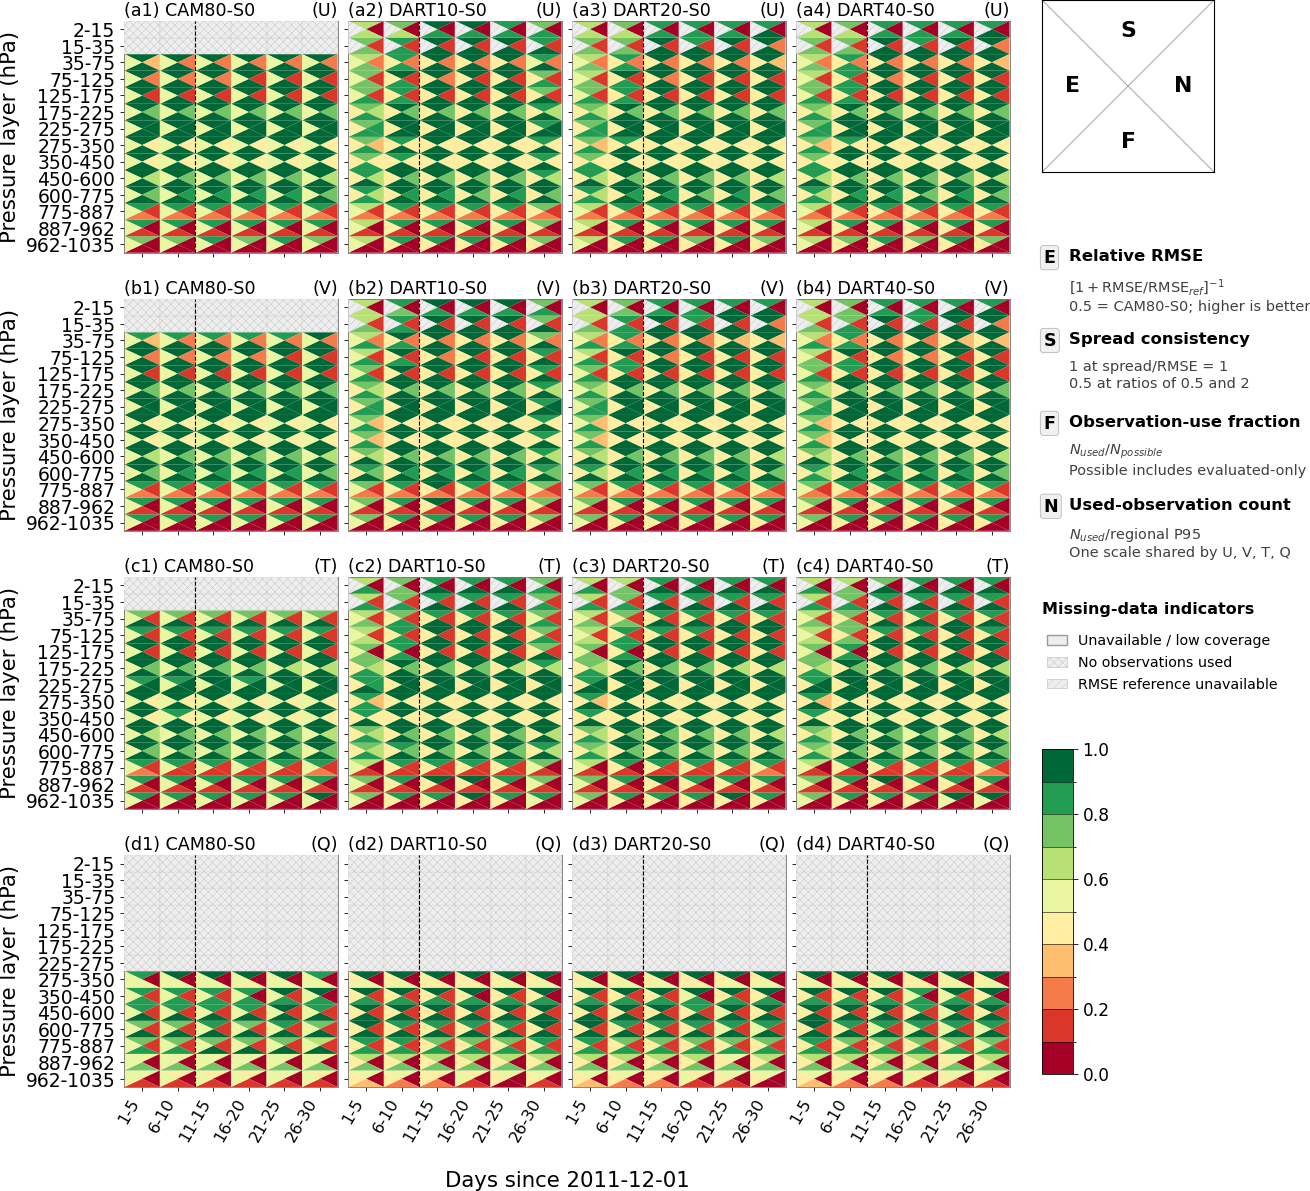

In [20]:
if FIGURE_TYPE == "metric_triangles":
    heatmap_contexts = prepare_heatmap_contexts()
    heatmap_panel_data = plot_metric_uvtq_heatmaps(
        heatmap_contexts, **final_heatmap_kwargs("raw", show=False, save=False)
    )
    triangle_figure, triangle_axes, triangle_scores = plot_triangle_metric_heatmaps(
        heatmap_contexts, heatmap_panel_data, **final_heatmap_kwargs("metric")
    )

## 9. Variable-triangle heatmaps

In [21]:
# Combined normalized heatmap with U, V, T, and Q as the four triangles
from matplotlib.colors import BoundaryNorm, ListedColormap


def plot_variable_triangle_heatmaps(
    contexts, normalized_scores, *, variable_layout=VARIABLE_TRIANGLE_LAYOUT,
    score_cmap=FINAL_HEATMAP_CONFIG["score_cmap"], score_boundaries=FINAL_HEATMAP_CONFIG["score_boundaries"], score_ticks=None,
    panel_width=FINAL_HEATMAP_CONFIG["panel_width"], panel_height=FINAL_HEATMAP_CONFIG["panel_width"] * FINAL_HEATMAP_CONFIG["panel_aspect_ratio"], column_space=FINAL_HEATMAP_CONFIG["column_space"], row_space=FINAL_HEATMAP_CONFIG["row_space"],
    spinup_end_day=FINAL_HEATMAP_CONFIG["spinup_end_day"], fontz=FINAL_HEATMAP_CONFIG["fontz"],
    dpi=PLOT_STYLE_CONFIG["overview_dpi"], show=True, save=True, outname=None,
):
    """Plot U/V/T/Q triangles for each normalized diagnostic metric."""
    positions = ("top", "right", "bottom", "left")
    if set(variable_layout) != set(positions):
        raise ValueError(f"variable_layout keys must be {list(positions)}")
    variables = tuple(variable_layout[position] for position in positions)
    if len(set(variables)) != 4:
        raise ValueError("Each triangle position must use a different variable.")
    missing_variables = [variable for variable in variables if variable not in contexts]
    if missing_variables:
        raise ValueError(f"Triangle variables are unavailable: {missing_variables}")

    metrics = ("rmse", "spread", "nused", "rejection_rate")
    metric_labels = {
        "rmse": "RMSE",
        "spread": "Spread/RMSE",
        "nused": "Assimilated count",
        "rejection_rate": "Rejection",
    }
    reference_variable = variables[0]
    experiments = list(contexts[reference_variable]["plotter"].data_dict)
    experiments = [
        experiment for experiment in experiments
        if all((variable, experiment) in normalized_scores for variable in variables)
    ]
    if not experiments:
        raise ValueError("No common experiments are available for the variable-triangle plot.")

    configured_levels = FINAL_HEATMAP_CONFIG.get("levels")
    levels = list(configured_levels) if configured_levels is not None else [
        level for level in contexts[reference_variable]["plotter"].plevstr
        if all(level in contexts[var]["plotter"].plevstr for var in variables)
    ]
    if not levels:
        raise ValueError("No common pressure levels are available for U, V, T, and Q.")

    nrows, ncols = len(metrics), len(experiments)
    sample_scores = normalized_scores[(reference_variable, experiments[0])][1]
    sample_nlev, sample_ntime = sample_scores[metrics[0]].shape
    fig = plt.figure(
        figsize=(panel_width * ncols + PLOT_STYLE_CONFIG["triangle_extra_width"], panel_height * nrows),
        constrained_layout=False,
    )
    outer = fig.add_gridspec(
        nrows, ncols, wspace=column_space, hspace=row_space,
    )
    fig.subplots_adjust(
        **PLOT_STYLE_CONFIG["triangle_margins"],
        wspace=column_space, hspace=row_space,
    )
    axes = np.empty((nrows, ncols), dtype=object)
    score_boundaries = np.asarray(score_boundaries, dtype=float)
    if (
        score_boundaries.ndim != 1 or score_boundaries.size < 3
        or not np.all(np.isfinite(score_boundaries))
        or np.any(np.diff(score_boundaries) <= 0)
        or score_boundaries[0] < 0.0 or score_boundaries[-1] > 1.0
    ):
        raise ValueError(
            "score_boundaries must be strictly increasing within [0, 1]."
        )
    score_ticks = score_boundaries if score_ticks is None else np.asarray(score_ticks, dtype=float)
    if score_ticks.ndim != 1 or not np.all(np.isfinite(score_ticks)):
        raise ValueError("score_ticks must be a finite one-dimensional sequence.")
    if np.any(score_ticks < score_boundaries[0]) or np.any(score_ticks > score_boundaries[-1]):
        raise ValueError("score_ticks must lie within score_boundaries.")
    base_cmap = plt.get_cmap(score_cmap) if isinstance(score_cmap, str) else score_cmap
    cmap_name = getattr(base_cmap, "name", "custom")
    interior_colors = base_cmap(np.linspace(0.0, 1.0, score_boundaries.size - 1))
    cmap = ListedColormap(interior_colors, name=f"{cmap_name}_discrete")
    cmap.set_bad(base_cmap.get_bad())
    cmap.set_under(base_cmap.get_under())
    cmap.set_over(base_cmap.get_over())
    norm = BoundaryNorm(score_boundaries, ncolors=cmap.N, clip=False)
    vertices_for = {
        "top": lambda x, y: [(x-.5, y+.5), (x+.5, y+.5), (x, y)],
        "right": lambda x, y: [(x+.5, y+.5), (x+.5, y-.5), (x, y)],
        "bottom": lambda x, y: [(x+.5, y-.5), (x-.5, y-.5), (x, y)],
        "left": lambda x, y: [(x-.5, y-.5), (x-.5, y+.5), (x, y)],
    }

    for row, metric in enumerate(metrics):
        for col, experiment in enumerate(experiments):
            ax = fig.add_subplot(outer[row, col])
            axes[row, col] = ax
            for spine in ax.spines.values():
                spine.set_linewidth(0.01)
                spine.set_color("black")
            ax.tick_params(width=0.10)
            reference_time, reference_set, reference_bins = normalized_scores[(
                reference_variable, experiment
            )]
            shape = reference_set[metric].shape
            if shape[0] != len(levels):
                raise ValueError(
                    f"Level count mismatch for {metric}: {shape[0]} versus {len(levels)}."
                )

            for position in positions:
                variable = variable_layout[position]
                plotted_time, score_set, used_bin_ids = normalized_scores[(
                    variable, experiment
                )]
                values_2d = score_set[metric]
                if values_2d.shape != shape or not np.array_equal(
                    plotted_time, reference_time
                ):
                    raise ValueError(
                        f"Variable alignment mismatch for {variable}, {experiment}, {metric}."
                    )
                if reference_bins is None:
                    if used_bin_ids is not None:
                        raise ValueError(
                            f"Unexpected bin IDs for {variable}, {experiment}, {metric}."
                        )
                elif not np.array_equal(used_bin_ids, reference_bins):
                    raise ValueError(
                        f"Five-day bin mismatch for {variable}, {experiment}, {metric}."
                    )
                polygons, values = [], []
                for ilev in range(shape[0]):
                    for itime in range(shape[1]):
                        polygons.append(vertices_for[position](itime, ilev))
                        values.append(values_2d[ilev, itime])
                ax.add_collection(PolyCollection(
                    polygons, array=np.ma.masked_invalid(np.asarray(values)),
                    cmap=cmap, norm=norm, edgecolors=PLOT_STYLE_CONFIG["cell_edge_color"], linewidths=PLOT_STYLE_CONFIG["cell_edge_width"],
                ))

            ax.set_xlim(-0.5, shape[1] - 0.5)
            ax.set_ylim(-0.5, shape[0] - 0.5)
            # Draw one box around every time–pressure cell.
            ax.vlines(
                np.arange(-0.5, shape[1] + 0.5, 1.0),
                -0.5, shape[0] - 0.5, colors=PLOT_STYLE_CONFIG["cell_edge_color"], linewidth=PLOT_STYLE_CONFIG["cell_edge_width"], zorder=PLOT_STYLE_CONFIG["grid_zorder"],
            )
            ax.hlines(
                np.arange(-0.5, shape[0] + 0.5, 1.0),
                -0.5, shape[1] - 0.5, colors=PLOT_STYLE_CONFIG["cell_edge_color"], linewidth=PLOT_STYLE_CONFIG["cell_edge_width"], zorder=PLOT_STYLE_CONFIG["grid_zorder"],
            )
            ax.set_aspect("auto")
            ax.tick_params(axis="both", width=PLOT_STYLE_CONFIG["tick_width"])
            if reference_bins is not None and spinup_end_day is not None:
                xmin_day = int(contexts[reference_variable]["xmin"])
                spinup_bin = int((spinup_end_day - 1 - xmin_day) / 5)
                separator_x = np.searchsorted(reference_bins, spinup_bin, side="right") - 0.5
                if -0.5 < separator_x < shape[1] - 0.5:
                    ax.axvline(separator_x, color=PLOT_STYLE_CONFIG["spinup_line_color"], linestyle=PLOT_STYLE_CONFIG["spinup_line_style"], linewidth=PLOT_STYLE_CONFIG["spinup_line_width"], zorder=PLOT_STYLE_CONFIG["spinup_line_zorder"])
            panel_label = f"({chr(ord('a') + row)}{col + 1}) "
            ax.set_title(f"{panel_label}{experiment}", loc="left", fontsize=fontz * FONT_SCALE_CONFIG["compact"], fontweight=PLOT_STYLE_CONFIG["experiment_fontweight"], pad=PLOT_STYLE_CONFIG["triangle_title_pad"])
            ax.set_title(metric_labels[metric], loc="right", fontsize=fontz * FONT_SCALE_CONFIG["compact"], pad=PLOT_STYLE_CONFIG["triangle_title_pad"])
            ax.set_yticks(np.arange(shape[0]))
            if col == 0:
                ax.set_yticklabels(levels, fontsize=fontz * FONT_SCALE_CONFIG["triangle_ytick"])
                ax.set_ylabel(
                    "Pressure layer", fontsize=fontz * FONT_SCALE_CONFIG["triangle_ylabel"]
                )
            else:
                ax.set_yticklabels([])

            if reference_bins is not None:
                xmin_day = int(contexts[reference_variable]["xmin"])
                tick_labels = [
                    f"{xmin_day + int(bid)*5 + 1}\u2013{xmin_day + int(bid)*5 + 5}"
                    for bid in reference_bins
                ]
                tick_positions = np.arange(shape[1])
            else:
                candidates = [
                    value for value in FINAL_HEATMAP_CONFIG["xticks"]
                    if reference_time[0] <= value <= reference_time[-1]
                ]
                tick_positions = np.interp(
                    candidates, reference_time, np.arange(shape[1])
                )
                tick_labels = [str(value) for value in candidates]
            ax.set_xticks(tick_positions)
            if row == nrows - 1:
                ax.set_xticklabels(
                    tick_labels, rotation=PLOT_STYLE_CONFIG["triangle_tick_rotation"], ha="right", fontsize=fontz * FONT_SCALE_CONFIG["triangle_tick"]
                )
            else:
                ax.set_xticklabels([])

    fig.supxlabel(PLOT_STYLE_CONFIG["shared_xlabel"], y=PLOT_STYLE_CONFIG["shared_xlabel_y"], fontsize=fontz * FONT_SCALE_CONFIG["triangle_xlabel"])

    # Boxed key showing which variable occupies each triangle.
    key_ax = fig.add_axes(PLOT_STYLE_CONFIG["key_axes"])
    key_ax.plot([0, 1], [0, 1], color=PLOT_STYLE_CONFIG["key_line_color"], linewidth=PLOT_STYLE_CONFIG["key_line_width"])
    key_ax.plot([0, 1], [1, 0], color=PLOT_STYLE_CONFIG["key_line_color"], linewidth=PLOT_STYLE_CONFIG["key_line_width"])
    key_ax.text(0.50, 0.78, "(U)", ha="center", va="center", fontsize=fontz * FONT_SCALE_CONFIG["variable_key"])
    key_ax.text(0.76, 0.50, "(V)", ha="center", va="center", fontsize=fontz * FONT_SCALE_CONFIG["variable_key"])
    key_ax.text(0.50, 0.22, "(T)", ha="center", va="center", fontsize=fontz * FONT_SCALE_CONFIG["variable_key"])
    key_ax.text(0.24, 0.50, "(Q)", ha="center", va="center", fontsize=fontz * FONT_SCALE_CONFIG["variable_key"])
    key_ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[])
    key_ax.set_box_aspect(PLOT_STYLE_CONFIG["key_box_aspect"])

    # Keep the colorbar outside the experiment GridSpec so it cannot distort
    # the width or spacing of the final experiment columns.
    cax = fig.add_axes(PLOT_STYLE_CONFIG["colorbar_axes"])
    cbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation=PLOT_STYLE_CONFIG["colorbar_orientation"],
        boundaries=score_boundaries, ticks=score_ticks, spacing=PLOT_STYLE_CONFIG["colorbar_spacing"],
        drawedges=PLOT_STYLE_CONFIG["colorbar_draw_edges"], extend=PLOT_STYLE_CONFIG["colorbar_extend"],
    )
    cbar.solids.set_edgecolor(PLOT_STYLE_CONFIG["colorbar_edge_color"])
    cbar.solids.set_linewidth(PLOT_STYLE_CONFIG["colorbar_edge_width"])
    cbar.set_label(PLOT_STYLE_CONFIG["colorbar_label"], fontsize=fontz)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter(PLOT_STYLE_CONFIG["colorbar_tick_format"]))
    cbar.ax.tick_params(labelsize=fontz * FONT_SCALE_CONFIG["compact"], width=PLOT_STYLE_CONFIG["tick_width"])
    fig.text(*PLOT_STYLE_CONFIG["better_position"], "Better", ha="center", va="bottom", fontsize=fontz * FONT_SCALE_CONFIG["compact"])
    fig.text(*PLOT_STYLE_CONFIG["worse_position"], "Worse", ha="center", va="top", fontsize=fontz * FONT_SCALE_CONFIG["compact"])

    if save:
        first_plotter = contexts[reference_variable]["plotter"]
        if outname is None:
            aggregation = FINAL_HEATMAP_CONFIG["time_aggregation"]
            outname = (
                f"fig_variable_tri_obsdiag_"
                f"{aggregation}_{first_plotter.region}.{PLOT_STYLE_CONFIG['triangle_format']}"
            )
        output = Path(first_plotter.fig_path) / outname
        fig.savefig(output, dpi=dpi, bbox_inches=PLOT_STYLE_CONFIG["save_bbox"])
        print(f"Saved {output}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, axes


In [22]:
if FIGURE_TYPE == "variable_triangles":
    heatmap_contexts = prepare_heatmap_contexts()
    heatmap_panel_data = plot_metric_uvtq_heatmaps(
        heatmap_contexts, **final_heatmap_kwargs("raw", show=False, save=False)
    )
    _, _, triangle_scores = plot_triangle_metric_heatmaps(
        heatmap_contexts, heatmap_panel_data,
        **final_heatmap_kwargs("metric", show=False, save=False),
    )
    variable_triangle_figure, variable_triangle_axes = plot_variable_triangle_heatmaps(
        heatmap_contexts, triangle_scores, **final_heatmap_kwargs("variable")
    )